In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import rasterio
import seaborn as sns
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.ops import nearest_points
from rasterio.sample import sample_gen
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import streamlit as st
import pydeck as pdk

## Carga de datos

In [2]:
df_catastro = pd.read_csv('data//sig_benito.csv')
gdf_colonias =gpd.read_file('data//colonias_iecm2022_.shp')
gdf_uso_suelo = gpd.read_file('data//uso-de-suelo.shp')
try:
    df_denue = pd.read_csv('data//INEGI_DENUE_26012026.csv', encoding='latin-1')
except UnicodeDecodeError:
    df_denue = pd.read_csv('data//INEGI_DENUE_26012026.csv', encoding='cp1252')
gdf_ubi_metro_lin = gpd.read_file('data//STC_Metro_lineas_utm14n.shp')
gdf_ubi_metro_est = gpd.read_file('data//STC_Metro_estaciones_utm14n.shp')
gdf_ubi_metrobus_lin = gpd.read_file('data//Metrobus_lineas.shp')
gdf_ubi_metrobus_est = gpd.read_file('data//Metrobus_estaciones.shp')
gdf_ubi_tren_ligero_est = gpd.read_file('data//STE_TrenLigero_estaciones_utm14n.shp')
gdf_ubi_tren_ligero_lin = gpd.read_file('data//STE_TrenLigero_linea_utm14n.shp')
gdf_ubi_red_lin = gpd.read_file('data//RTP_lineas.shp')
gdf_ubi_red_prd = gpd.read_file('data//RTP_paradas.shp')


In [3]:
# 1. Conectar con el archivo descargado de Copernicus
with rasterio.open('data//benitojuarez.tiff') as dataset:
    
    # 2. Consultar la "identidad" de la imagen (Metadatos)
    sistema_coordenadas = dataset.crs
    geotransformacion = dataset.transform  # Relación píxel -> coordenada
    
    # 3. Leer los datos numéricos de la Banda 1 (NDVI)
    # Se convierte en una matriz de NumPy para que sea veloz
    matriz_ndvi = dataset.read(1)
    
    # 4. Verificación de seguridad
    print(f"Sistema de Coordenadas: {sistema_coordenadas}")
    print(f"Dimensiones de la imagen: {matriz_ndvi.shape}")

Sistema de Coordenadas: EPSG:4326
Dimensiones de la imagen: (297, 437)


## Análisis Exploratorio de Datos (EDA)

Como se puede observar se han ingresado varias fuentes de datos, el paso a continuación será examinar cada fuente de datos y ver qué información contiene y en qué formato se presentan esos datos, con el fin de eliminar la información que no será relevante para el modelo y en caso de ser necesario cambiar el formato de éstos.

### df_catastro

In [4]:
def auditoria_dats(df):
    info_df = pd.DataFrame({
        'Tipo de Dato':df.dtypes,
        'Valores Nulos' : df.isnull().sum(),
        '% Nulos': (df.isnull().sum()/len(df)*100).round(2),
        'Valores únicos': df.nunique()
    })

    print(info_df)
    display(df.head(3))

auditoria_dats(df_catastro)
print(type(df_catastro))

                           Tipo de Dato  Valores Nulos  % Nulos  \
codigo_postal                   float64             18     0.01   
superficie_terreno              float64              0     0.00   
superficie_construccion         float64              0     0.00   
uso_construccion                 object            842     0.35   
clave_rango_nivel                object              1     0.00   
anio_construccion               float64              7     0.00   
instalaciones_especiales         object              0     0.00   
valor_unitario_suelo            float64              0     0.00   
valor_suelo                     float64            497     0.20   
clave_valor_unitario_suelo       object              0     0.00   
subsidio                        float64              0     0.00   
latitud                         float64              0     0.00   
longitud                        float64              0     0.00   
colonia                          object              0     0.0

,codigo_postal,superficie_terreno,superficie_construccion,uso_construccion,clave_rango_nivel,anio_construccion,instalaciones_especiales,valor_unitario_suelo,valor_suelo,clave_valor_unitario_suelo,subsidio,latitud,longitud,colonia,alcaldia
0,3400.0,122.0,267.0,Habitacional,02,1988.0,Sí,5340.32,651519.04,A030044,704.22,19.403473,-99.142873,ALAMOS I,BENITO JUAREZ
1,3400.0,110.0,84.0,Habitacional,02,1970.0,No,5340.32,587435.20,A030044,706.31,19.403478,-99.142968,ALAMOS I,BENITO JUAREZ
2,3400.0,99.0,200.0,Habitacional,02,1970.0,Sí,5340.32,528691.68,A030044,640.79,19.403482,-99.143053,ALAMOS I,BENITO JUAREZ


<class 'pandas.core.frame.DataFrame'>


In [5]:
# Borrar columnas que no aportan información relevante al modelo
df_catastro = df_catastro.drop(['alcaldia','subsidio','instalaciones_especiales','clave_valor_unitario_suelo','codigo_postal'], axis=1)

#Limpieza de columnas de texto
columnas_texto = ['uso_construccion','colonia']
for col in columnas_texto:
    df_catastro[col] = df_catastro[col].astype(str).str.upper().str.strip()

#Convertir valores nulos a cero para su posterior imputacion
# La estructura correcta es: df.loc[condicion, 'columna'] = nuevo_valor
df_catastro.loc[df_catastro['anio_construccion'] <= 0, 'anio_construccion'] = None
#Imputar
df_catastro['anio_construccion'] = df_catastro.groupby('colonia')['anio_construccion'].transform(lambda x : x.fillna(x.median()))
#Convertir a entero
df_catastro['anio_construccion'] = df_catastro['anio_construccion'].astype('Int64')

auditoria_dats(df_catastro)


                        Tipo de Dato  Valores Nulos  % Nulos  Valores únicos
superficie_terreno           float64              0      0.0           13374
superficie_construccion      float64              0      0.0           27263
uso_construccion              object              0      0.0               8
clave_rango_nivel             object              1      0.0               8
anio_construccion              Int64              0      0.0             103
valor_unitario_suelo         float64              0      0.0              53
valor_suelo                  float64            497      0.2           38472
latitud                      float64              0      0.0           45227
longitud                     float64              0      0.0           45227
colonia                       object              0      0.0              64


,superficie_terreno,superficie_construccion,uso_construccion,clave_rango_nivel,anio_construccion,valor_unitario_suelo,valor_suelo,latitud,longitud,colonia
0,122.0,267.0,HABITACIONAL,02,1988,5340.32,651519.04,19.403473,-99.142873,ALAMOS I
1,110.0,84.0,HABITACIONAL,02,1970,5340.32,587435.20,19.403478,-99.142968,ALAMOS I
2,99.0,200.0,HABITACIONAL,02,1970,5340.32,528691.68,19.403482,-99.143053,ALAMOS I


In [6]:
# Trabajar con los valores nulos
df_catastro['valor_suelo'] = df_catastro['valor_suelo'].fillna(df_catastro['superficie_terreno']* df_catastro['valor_unitario_suelo'])

#Función par aobtener la moda de una columna

def get_moda(x):
    mode = x.mode()
    return mode.iloc[0] if not mode.empty else None

# Aplicar imputación por colonia columnas con valores nulos
for col in ['uso_construccion','clave_rango_nivel']:
    df_catastro[col] = df_catastro.groupby('colonia')[col].transform(lambda x : x.fillna(get_moda(x)))

auditoria_dats(df_catastro)

                        Tipo de Dato  Valores Nulos  % Nulos  Valores únicos
superficie_terreno           float64              0      0.0           13374
superficie_construccion      float64              0      0.0           27263
uso_construccion              object              0      0.0               8
clave_rango_nivel             object              0      0.0               8
anio_construccion              Int64              0      0.0             103
valor_unitario_suelo         float64              0      0.0              53
valor_suelo                  float64              0      0.0           38702
latitud                      float64              0      0.0           45227
longitud                     float64              0      0.0           45227
colonia                       object              0      0.0              64


,superficie_terreno,superficie_construccion,uso_construccion,clave_rango_nivel,anio_construccion,valor_unitario_suelo,valor_suelo,latitud,longitud,colonia
0,122.0,267.0,HABITACIONAL,02,1988,5340.32,651519.04,19.403473,-99.142873,ALAMOS I
1,110.0,84.0,HABITACIONAL,02,1970,5340.32,587435.20,19.403478,-99.142968,ALAMOS I
2,99.0,200.0,HABITACIONAL,02,1970,5340.32,528691.68,19.403482,-99.143053,ALAMOS I


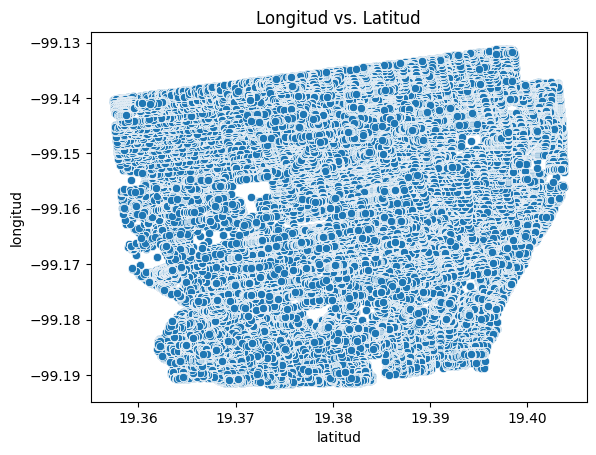

In [7]:
# Ya no se tienen valores nulos, sin embargo solo como observación se revisará que las coordenadas se encuentren dentro del el rango correcto
sns.scatterplot(data=df_catastro, x='latitud', y='longitud')
plt.title('Longitud vs. Latitud')
plt.show()

In [8]:
#Ahora hay que identificar si hay errores de dedo en valor_unitario o superficie
# Eliminar valores imposibles
df_catastro = df_catastro[(df_catastro['superficie_terreno'] > 0) & 
                          (df_catastro['valor_unitario_suelo'] > 0)]

auditoria_dats(df_catastro)

                        Tipo de Dato  Valores Nulos  % Nulos  Valores únicos
superficie_terreno           float64              0      0.0           13373
superficie_construccion      float64              0      0.0           27254
uso_construccion              object              0      0.0               8
clave_rango_nivel             object              0      0.0               8
anio_construccion              Int64              0      0.0             103
valor_unitario_suelo         float64              0      0.0              53
valor_suelo                  float64              0      0.0           38701
latitud                      float64              0      0.0           45227
longitud                     float64              0      0.0           45227
colonia                       object              0      0.0              64


,superficie_terreno,superficie_construccion,uso_construccion,clave_rango_nivel,anio_construccion,valor_unitario_suelo,valor_suelo,latitud,longitud,colonia
0,122.0,267.0,HABITACIONAL,02,1988,5340.32,651519.04,19.403473,-99.142873,ALAMOS I
1,110.0,84.0,HABITACIONAL,02,1970,5340.32,587435.20,19.403478,-99.142968,ALAMOS I
2,99.0,200.0,HABITACIONAL,02,1970,5340.32,528691.68,19.403482,-99.143053,ALAMOS I


In [9]:
#En esta parte ya se han limpiado los datos, pero hay que verificar que los datos no haya duplicado,outliers
def limpieza_pro_catastro(gdf):
    temp = gdf.copy()
    antes = len(temp)
    
    # 1. Eliminar filas con valores en 0 que no tienen sentido
    temp = temp[(temp['superficie_terreno']>0) &
            (temp['superficie_construccion']>0) &
            (temp['valor_suelo']>0)]
    
    # 2. Corregir años de construcción (ejemplo: 1900 a 2026)
    # Si están fuera de rango, los marcamos como nulos o los quitamos
    temp = temp[(temp['anio_construccion']>= 1900) & (temp['anio_construccion']<=2026)]
    
    # 3. Quitar duplicados por ubicación exacta (Lat/Lon)
    temp = temp.drop_duplicates(subset=['latitud', 'longitud','superficie_construccion'])
    
    # 4. Resetear índice
    temp = temp.reset_index(drop=True)


    
    print(f"Catastro pulido: Se eliminaron {antes - len(temp)} registros inconsistentes.")
    print(f"Registros listos para el modelo: {len(temp)}")
    return temp

# Ejecutamos
gdf_catastro_final = limpieza_pro_catastro(df_catastro)
print(type(gdf_catastro_final))

Catastro pulido: Se eliminaron 135529 registros inconsistentes.
Registros listos para el modelo: 107977
<class 'pandas.core.frame.DataFrame'>


In [10]:
#Como último paso en archivo se debe convertir en un GeoDataFrame
gdf_catastro = gpd.GeoDataFrame(
    df_catastro,
    geometry= gpd.points_from_xy(df_catastro['longitud'], df_catastro['latitud']),
    crs="EPSG:4326"
)

print(F'Los datos ahora son: {type(gdf_catastro)}')
print(f"Catastro: {gdf_catastro.crs}")
print(f"Colonias: {gdf_colonias.crs}")

Los datos ahora son: <class 'geopandas.geodataframe.GeoDataFrame'>
Catastro: EPSG:4326
Colonias: EPSG:4326


In [11]:
#Pasemos al siguiente df
auditoria_dats(df_denue)

                                                   Tipo de Dato  \
ID                                                        int64   
Clee                                                     object   
Nombre de la Unidad Económica                            object   
Razón social                                             object   
Código de la clase de actividad SCIAN                     int64   
Nombre de clase de la actividad                          object   
Descripcion estrato personal ocupado                     object   
Tipo de vialidad                                         object   
Nombre de la vialidad                                    object   
Tipo de entre vialidad 1                                 object   
Nombre de entre vialidad 1                               object   
Tipo de entre vialidad 2                                 object   
Nombre de entre vialidad 2                               object   
Tipo de entre vialidad 3                                 objec

,ID,Clee,Nombre de la Unidad Económica,Razón social,Código de la clase de actividad SCIAN,Nombre de clase de la actividad,Descripcion estrato personal ocupado,Tipo de vialidad,Nombre de la vialidad,Tipo de entre vialidad 1,...,Localidad,Área geoestadística básica,Manzana,Número de teléfono,Correo electrónico,Sitio en Internet,Tipo de establecimiento,Latitud,Longitud,Fecha de incorporación al DENUE
0,6312958,09014462210000031000021645S3,0494 SUBURBIA HOLBEIN,SUBURBIA S DE RL DE CV,462210,Comercio al por menor en tiendas departamentales,51 a 100 personas,AVENIDA,HOLBEIN,EJE VIAL,...,Benito Juárez,0577,30,NaN,CONTACTO@SUBURBIA.COM.MX,WWW.SUBURBIA.COM.MX,Fijo,19.382938,-99.176138,2010-07
1,6313227,09014462210000021001021645S4,0497 SUBURBIA PARROQUIA,SUBURBIA S DE RL DE CV,462210,Comercio al por menor en tiendas departamentales,101 a 250 personas,CALLE,PARROQUIA,AVENIDA,...,Benito Juárez,0825,2,NaN,CONTACTO@SUBURBIA.COM.MX,WWW.SUBURBIA.COM.MX,Fijo,19.368133,-99.165185,2010-07
2,6313045,09014461190000992001002496S1,07440 EL GLOBO HOLBEIN,TRADICION EN PASTELERIAS SA DE CV,461190,Comercio al por menor de otros alimentos,6 a 10 personas,AVENIDA,INSURGENTES SUR,ANDADOR,...,Benito Juárez,0577,38,NaN,MIGUEL.SUAREZ@GRUPOBIMBO.COM,WWW.ELGLOBO.COM.MX,Fijo,19.382637,-99.176227,2010-07


In [12]:
#Primer paso eliminar todas las columnas que no son relevantes
df_denue = df_denue.drop(['Número de teléfono','Correo electrónico','Sitio en Internet','Tipo de vialidad','Nombre de la vialidad','Tipo de entre vialidad 1','Nombre de entre vialidad 1','Tipo de entre vialidad 2','Nombre de entre vialidad 2','Tipo de entre vialidad 3','Nombre de entre vialidad 3','Número exterior o kilómetro','Letra exterior','Edificio','Edificio Piso','Número interior','Letra interior','Entidad federativa','Municipio','Localidad','Clave municipio','Manzana','Clee','ID','Fecha de incorporación al DENUE','Razón social','Clave entidad','Clave localidad'],axis=1)

auditoria_dats(df_denue)

                                                   Tipo de Dato  \
Nombre de la Unidad Económica                            object   
Código de la clase de actividad SCIAN                     int64   
Nombre de clase de la actividad                          object   
Descripcion estrato personal ocupado                     object   
Tipo de asentamiento humano                              object   
Nombre de asentamiento humano                            object   
Tipo centro comercial                                    object   
Corredor industrial, centro comercial o mercado...       object   
Número de local                                          object   
Código Postal                                           float64   
Área geoestadística básica                               object   
Tipo de establecimiento                                  object   
Latitud                                                 float64   
Longitud                                                float6

,Nombre de la Unidad Económica,Código de la clase de actividad SCIAN,Nombre de clase de la actividad,Descripcion estrato personal ocupado,Tipo de asentamiento humano,Nombre de asentamiento humano,Tipo centro comercial,"Corredor industrial, centro comercial o mercado público",Número de local,Código Postal,Área geoestadística básica,Tipo de establecimiento,Latitud,Longitud
0,0494 SUBURBIA HOLBEIN,462210,Comercio al por menor en tiendas departamentales,51 a 100 personas,COLONIA,NOCHE BUENA,NaN,NaN,NaN,3720.0,0577,Fijo,19.382938,-99.176138
1,0497 SUBURBIA PARROQUIA,462210,Comercio al por menor en tiendas departamentales,101 a 250 personas,COLONIA,SANTA CRUZ ATOYAC,CENTRO Y PLAZA COMERCIAL,UNIVERSIDAD,SN,3310.0,0825,Fijo,19.368133,-99.165185
2,07440 EL GLOBO HOLBEIN,461190,Comercio al por menor de otros alimentos,6 a 10 personas,COLONIA,NAPOLES,NaN,NaN,NaN,3810.0,0577,Fijo,19.382637,-99.176227


In [13]:
#La columna SCIAN debe ser texto para evitar que se modifiquen algunos datos que pueden contener 0 al comienzo
df_denue['Código de la clase de actividad SCIAN'] = df_denue['Código de la clase de actividad SCIAN'].astype(str)

#Manejar valores nulos 
cols_comerciales = ['Tipo centro comercial','Corredor industrial, centro comercial o mercado público','Número de local']

for col in cols_comerciales:
    if col in df_denue.columns:
        df_denue[col] =df_denue[col].fillna('ESTABLECIMIENTO INDEPENDIENTE')

cols_asentamientos = ['Tipo de asentamiento humano','Nombre de asentamiento humano']
for col in cols_asentamientos:
    if col in df_denue:
        df_denue[col] = df_denue[col].fillna('SIN DATO')

df_denue['Código Postal'] = df_denue['Código Postal'].fillna(0).astype(int).astype(str).str.zfill(5)
auditoria_dats(df_denue)


                                                   Tipo de Dato  \
Nombre de la Unidad Económica                            object   
Código de la clase de actividad SCIAN                    object   
Nombre de clase de la actividad                          object   
Descripcion estrato personal ocupado                     object   
Tipo de asentamiento humano                              object   
Nombre de asentamiento humano                            object   
Tipo centro comercial                                    object   
Corredor industrial, centro comercial o mercado...       object   
Número de local                                          object   
Código Postal                                            object   
Área geoestadística básica                               object   
Tipo de establecimiento                                  object   
Latitud                                                 float64   
Longitud                                                float6

,Nombre de la Unidad Económica,Código de la clase de actividad SCIAN,Nombre de clase de la actividad,Descripcion estrato personal ocupado,Tipo de asentamiento humano,Nombre de asentamiento humano,Tipo centro comercial,"Corredor industrial, centro comercial o mercado público",Número de local,Código Postal,Área geoestadística básica,Tipo de establecimiento,Latitud,Longitud
0,0494 SUBURBIA HOLBEIN,462210,Comercio al por menor en tiendas departamentales,51 a 100 personas,COLONIA,NOCHE BUENA,ESTABLECIMIENTO INDEPENDIENTE,ESTABLECIMIENTO INDEPENDIENTE,ESTABLECIMIENTO INDEPENDIENTE,03720,0577,Fijo,19.382938,-99.176138
1,0497 SUBURBIA PARROQUIA,462210,Comercio al por menor en tiendas departamentales,101 a 250 personas,COLONIA,SANTA CRUZ ATOYAC,CENTRO Y PLAZA COMERCIAL,UNIVERSIDAD,SN,03310,0825,Fijo,19.368133,-99.165185
2,07440 EL GLOBO HOLBEIN,461190,Comercio al por menor de otros alimentos,6 a 10 personas,COLONIA,NAPOLES,ESTABLECIMIENTO INDEPENDIENTE,ESTABLECIMIENTO INDEPENDIENTE,ESTABLECIMIENTO INDEPENDIENTE,03810,0577,Fijo,19.382637,-99.176227


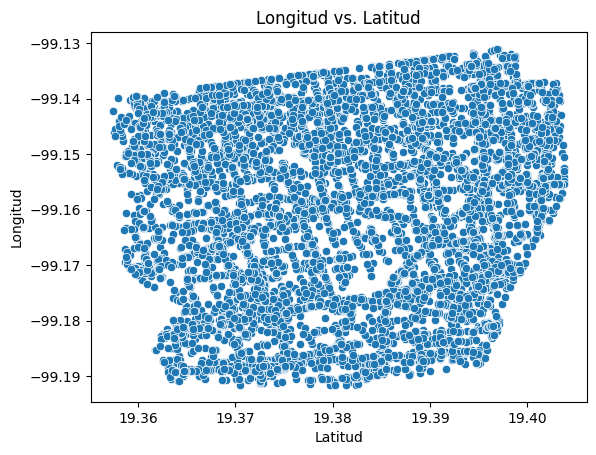

In [14]:
sns.scatterplot(data=df_denue, x='Latitud', y='Longitud')
plt.title('Longitud vs. Latitud')
plt.show()

In [15]:
#Como último paso en archivo se debe convertir en un GeoDataFrame
gdf_denue = gpd.GeoDataFrame(
    df_denue,
    geometry= gpd.points_from_xy(df_denue['Longitud'], df_denue['Latitud']),
    crs="EPSG:4326"
)

print(F'Los datos ahora son: {type(gdf_denue)}')
print(f"Catastro: {gdf_catastro.crs}")
print(f"Colonias: {gdf_colonias.crs}")
print(f"Denue: {gdf_denue.crs}")
print(type(gdf_denue))

Los datos ahora son: <class 'geopandas.geodataframe.GeoDataFrame'>
Catastro: EPSG:4326
Colonias: EPSG:4326
Denue: EPSG:4326
<class 'geopandas.geodataframe.GeoDataFrame'>


## Limpieza de Archivos de Movilidad, Colonias y Uso de Suelo

['ENTIDAD', 'CDT', 'DEMARCACIO', 'DISTRITOLO', 'DISTRITOL2', 'CVEUT', 'UT', 'SECCCOMPL', 'SECCPARC', 'POBL', 'geometry']
['ALVARO OBREGON' 'AZCAPOTZALCO' 'BENITO JUAREZ' 'COYOACAN'
 'CUAJIMALPA DE MORELOS' 'CUAUHTEMOC' 'GUSTAVO A. MADERO' 'IZTACALCO'
 'IZTAPALAPA' 'LA MAGDALENA CONTRERAS' 'MIGUEL HIDALGO' 'MILPA ALTA'
 'TLAHUAC' 'TLALPAN' 'VENUSTIANO CARRANZA' 'XOCHIMILCO']
Número de colonias detectadas: 64


C:\Users\Carlos\AppData\Local\Temp\ipykernel_14424\3384534196.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poligono_bj = colonias_bj.unary_union


<Axes: >

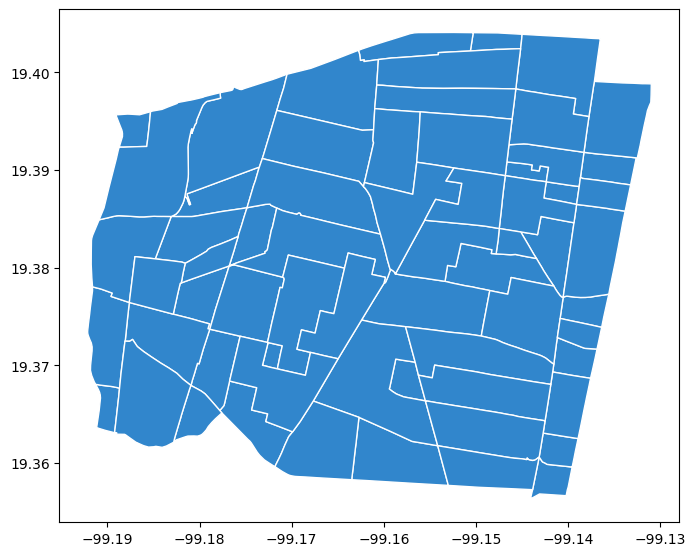

In [16]:
#Filtrar colonias por Alcaldía Benito Juarez
print(gdf_colonias.columns.tolist())
print(gdf_colonias['DEMARCACIO'].unique())

# Buscamos la alcaldia Benito Juarez'
colonias_bj = gdf_colonias[gdf_colonias['DEMARCACIO'].str.contains('BENITO JUAREZ', case=False, na=False)]

# Pero primero confirmemos cuántas colonias agarró:
print(f"Número de colonias detectadas: {len(colonias_bj)}")
poligono_bj = colonias_bj.unary_union
colonias_bj.plot(figsize=(8,8), edgecolor='white',color='#3186cc')

In [17]:
#Camibar nombre de columnas y asegurarnos que el tipo sea "EPSG:4326"
gdfs = [gdf_ubi_metro_est,gdf_ubi_metro_lin,gdf_ubi_metrobus_est,gdf_ubi_metrobus_lin,gdf_ubi_red_lin,gdf_ubi_red_prd,gdf_ubi_tren_ligero_est,gdf_ubi_tren_ligero_lin]

def limpiar_gdf(lista):
    lista_limpia = []
    for gd in lista:
        gd.columns = [str(c).strip().lower().replace(' ','_') for c in gd.columns]
        if gd.crs != "EPSG:4326":
            gd = gd.to_crs("EPSG:4326")
        lista_limpia.append(gd)  
    return lista_limpia

gdfs_limpios = limpiar_gdf(gdfs)
print(gdfs_limpios)

[       sistema                  nombre linea est  cve_est cve_eod17  \
0    STC Metro               Pantitlán    01  01  STC0101     05014   
1    STC Metro                Zaragoza    01  02  STC0102     05020   
2    STC Metro            Gomez Farías    01  03  STC0103     05007   
3    STC Metro  Boulevard Puerto Aéreo    01  04  STC0104     05003   
4    STC Metro                Balbuena    01  05  STC0105     05001   
..         ...                     ...   ...  ..      ...       ...   
190  STC Metro                 Múzquiz     B  17  STCLB17     05185   
191  STC Metro                Ecatepec     B  18  STCLB18     05179   
192  STC Metro                Olímpica     B  19  STCLB19     05188   
193  STC Metro            Plaza Aragón     B  20  STCLB20     05189   
194  STC Metro           Ciudad Azteca     B  21  STCLB21     05177   

                      tipo                    alcaldias   año  \
0    Terminal / Transbordo          Venustiano Carranza  1984   
1               

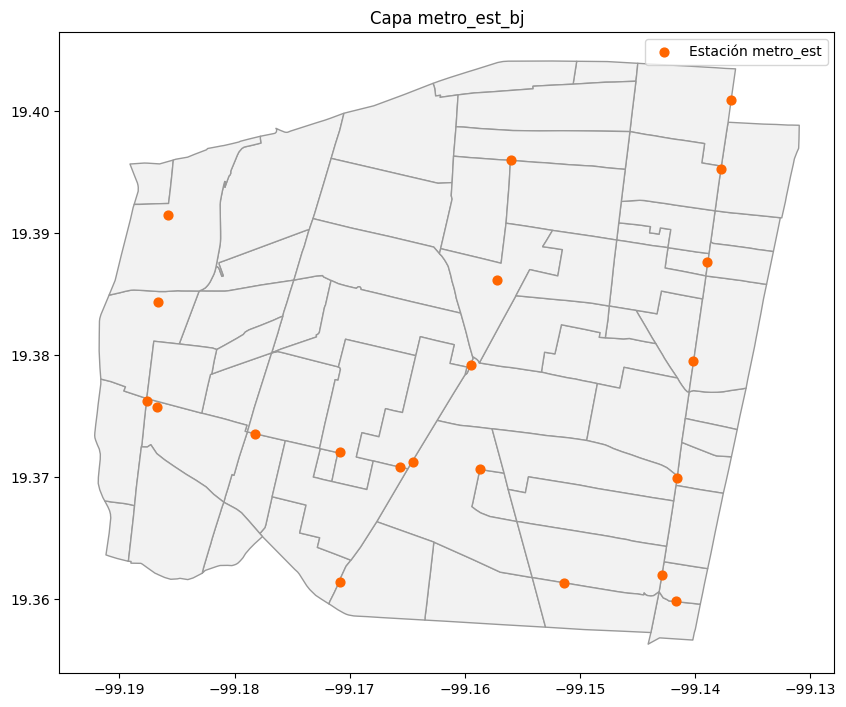

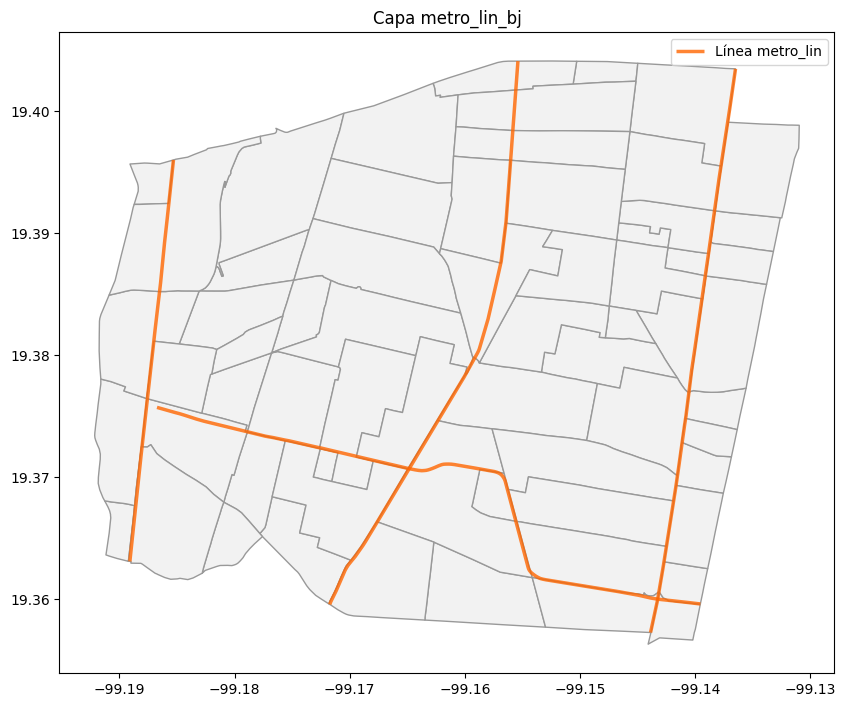

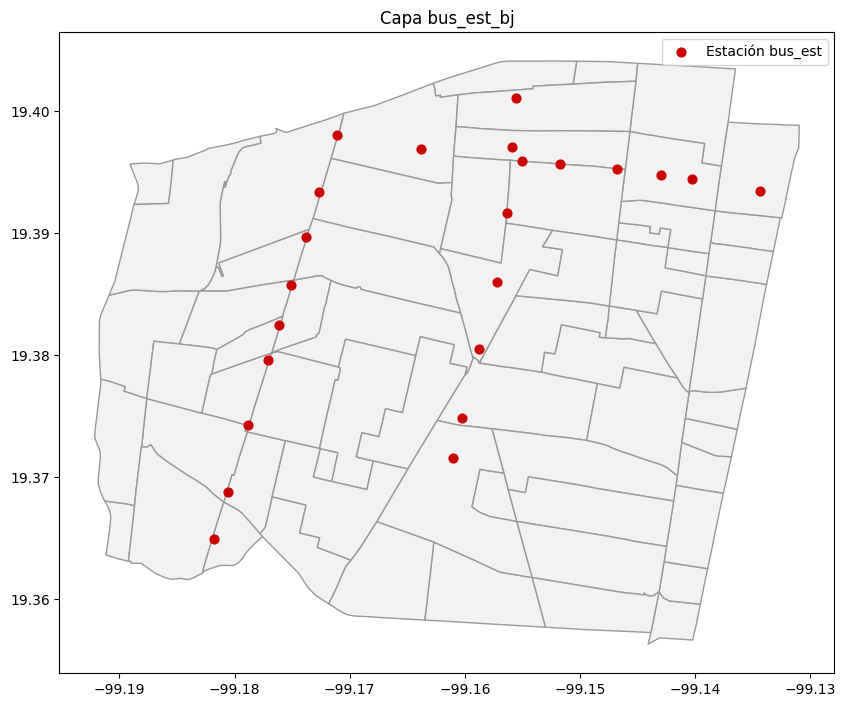

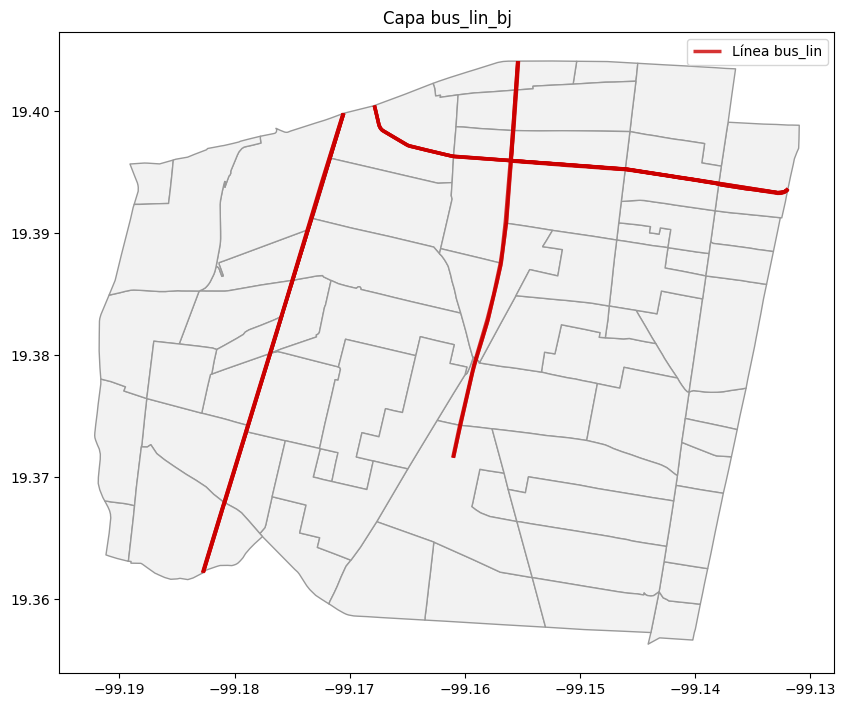

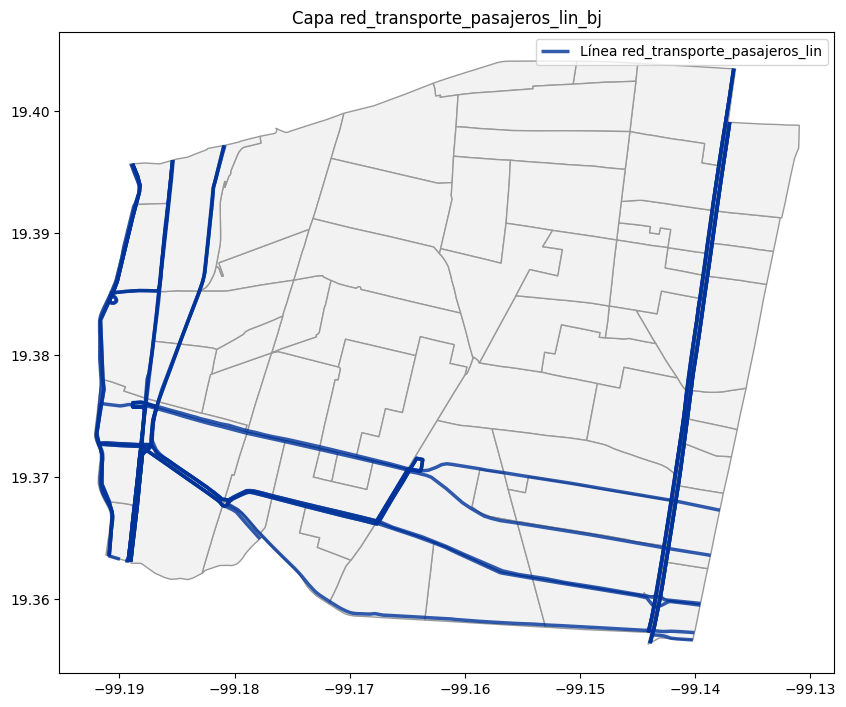

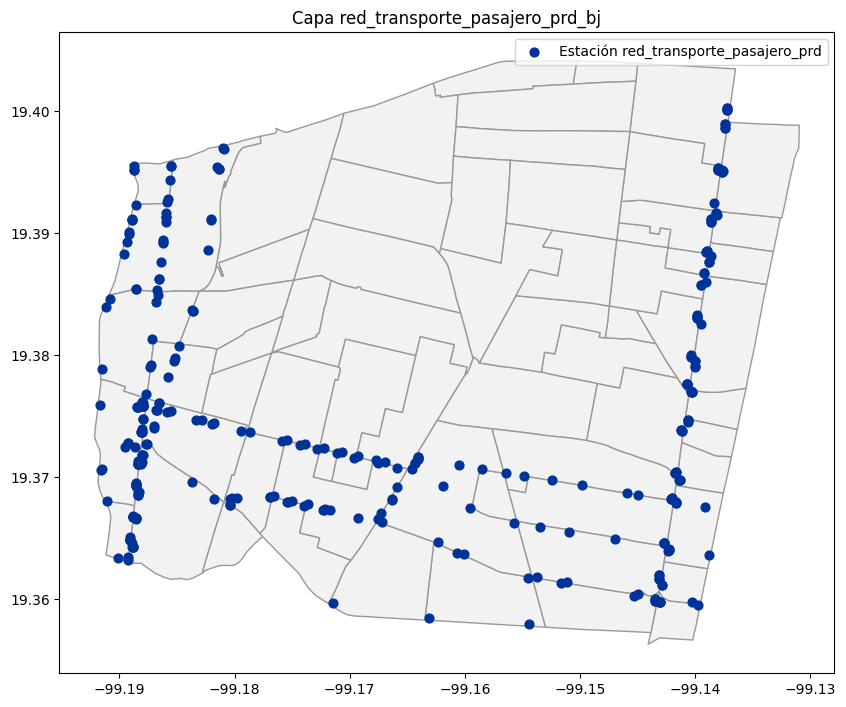

tren_ligero_est: No tiene presencia en la Alcaldía Benito Juárez
tren_ligero_lin: No tiene presencia en la Alcaldía Benito Juárez


In [18]:
#Filtrar solo la movilidad que afecta a Benito Juarez
#Crear un poligono que delimite 
def procesar_mov_bj(archivos, nombres):
    diccionario_recortados= {}
    #Asignar a cada tipo de transporte un color
    color_transporte = {
        'metro':'#FF6600',
        'bus':'#CC0000',
        'red':'#003399',
        'tren':'#009933'
    }

    for gd, nombre in zip(archivos, nombres):
        #Cambiar el nombre al archivo
        nuevo_nombre = f'{nombre}_bj'
        #Crear la union
        gd_bj = gd.clip(poligono_bj)
        # Determinar el color según el nombre
        color_capa = 'Gray'
        for clave, color in color_transporte.items():
            if clave in nombre.lower():
                color_capa = color
                break
        if gd_bj.empty:
            print(f'{nombre}: No tiene presencia en la Alcaldía Benito Juárez')
            continue

        #Graficar
        fig,ax = plt.subplots(figsize=(10,10))
        colonias_bj.plot(ax=ax, color='#f2f2f2', edgecolor='#999999', zorder=1)
        # Estaciones
        if 'est' in nombre.lower() or 'prd' in nombre.lower():
            gd_bj.plot(ax=ax,color=color_capa,markersize=40, zorder=3, label=f'Estación {nombre}')
        elif 'lin' in nombre.lower():
            gd_bj.plot(ax=ax, color= color_capa, linewidth=2.5, alpha=0.8, zorder=2, label=f'Línea {nombre}')
        plt.title(f'Capa {nuevo_nombre}')
        plt.legend()
        plt.show()

        # E) Guardar en el diccionario con el nuevo nombre
        diccionario_recortados[nuevo_nombre] = gd_bj
        
    return diccionario_recortados
    

# --- CÓMO USARLO ---
nombres = ['metro_est', 'metro_lin', 'bus_est', 'bus_lin', 'red_transporte_pasajeros_lin', 'red_transporte_pasajero_prd','tren_ligero_est','tren_ligero_lin']
mis_gdfs_bj = procesar_mov_bj(gdfs_limpios , nombres)

# Para acceder a uno específico:
# metro_bj = mis_gdfs_bj['metro_est_bj']

In [19]:
#Una vez con los archivos solapados es menester cambiar de formato estos para poder medir las distancias entre estas ubicaciones.
def pre_final(diccionario):
    gdfs_finales = {}
    
    # 1. Usamos .items() para tener la 'clave' (nombre) y el 'gd' (los datos)
    for clave, gd in diccionario.items():
        
        # 2. Cambiar medida a metros (Si no está ya en 6372)
        if gd.crs != "EPSG:6372":
            gd = gd.to_crs("EPSG:6372")
        
        # 3. Validar geometrías
        gd['geometry'] = gd.geometry.make_valid()
        
        # 4. Selección Inteligente de Columnas
        # Agregamos las que suelen ser importantes en movilidad
        columnas_posibles = ['geometry', 'nombre', 'estacion', 'linea', 'tipo']
        # Solo mantenemos las que realmente existan en este archivo específico
        columnas_a_mantener = [c for c in columnas_posibles if c in gd.columns]
        
        # Si por alguna razón no hay ninguna de las anteriores, al menos dejamos geometry
        if 'geometry' not in columnas_a_mantener:
            columnas_a_mantener.append('geometry')

        # 5. Guardar el resultado limpio en el nuevo diccionario
        gdfs_finales[clave] = gd[columnas_a_mantener]
        
        
    return gdfs_finales

finales_movilidad = pre_final(mis_gdfs_bj)
print(finales_movilidad)

{'metro_est_bj':                                geometry                             nombre  \
40   POINT Z (2799424.573 822123.441 0)                           Portales   
39   POINT Z (2799548.558 823186.658 0)                          Nativitas   
38    POINT Z (2799659.52 824077.499 0)                    Villa de Cortés   
37    POINT Z (2799763.253 824921.79 0)                               Xola   
36   POINT Z (2799845.932 825548.101 0)                           Viaducto   
60   POINT Z (2796375.663 821117.283 0)                           Coyoacán   
161  POINT Z (2796350.063 822293.052 0)           Hospital 20 de Noviembre   
162  POINT Z (2795575.264 822447.817 0)                    Insurgentes Sur   
163  POINT Z (2794682.424 822667.127 0)                            Mixcoac   
111  POINT Z (2794591.992 822726.922 0)                            Mixcoac   
157  POINT Z (2799440.739 821008.531 0)                             Ermita   
158  POINT Z (2798411.744 821155.621 0)        

In [20]:
#Como último paso antes de revisar el documento de uso de suelo hay que validar que no haya nuños, duplicados e indice
def revision_lim(diccionario):
    for nombre, gd in diccionario.items():
        print(f'Archivo: {nombre}')
        #Revisar nulos
        nulos = gd.isnull().sum()
        # 2. Verificar Duplicados Geométricos
        dups_geo = gd.geometry.duplicated().sum()
        col_nom = next((c for c in ['nombre', 'estacion','linea'] if c in gd.columns), None)
        dups_nom = gd[col_nom].duplicated().sum() if col_nom else "N/A"

        print(f"   Total registros: {len(gd)}")
        print(f"   Valores nulos: {nulos}")
        print(f"   Duplicados geométricos: {dups_geo}")
        print(f"   Duplicados por nombre ({col_nom}): {dups_nom}")
        print("-" * 30)

# Ejecutar auditoría
revision_lim(mis_gdfs_bj)

Archivo: metro_est_bj
   Total registros: 21
   Valores nulos: sistema      0
nombre       0
linea        0
est          0
cve_est      0
cve_eod17    0
tipo         0
alcaldias    0
año          0
geometry     0
dtype: int64
   Duplicados geométricos: 0
   Duplicados por nombre (nombre): 3
------------------------------
Archivo: metro_lin_bj
   Total registros: 4
   Valores nulos: sistema     0
linea       0
ruta        0
geometry    0
dtype: int64
   Duplicados geométricos: 0
   Duplicados por nombre (linea): 0
------------------------------
Archivo: bus_est_bj
   Total registros: 23
   Valores nulos: sistema      0
nombre       0
linea        0
est          0
cve_eod17    5
tipo         0
alcaldias    0
año          0
cve_est      0
geometry     0
dtype: int64
   Duplicados geométricos: 0
   Duplicados por nombre (nombre): 1
------------------------------
Archivo: bus_lin_bj
   Total registros: 13
   Valores nulos: sistema     0
ruta        0
tramo       0
linea       0
geometry    

In [21]:
def limpieza_final_produccion(diccionario):
    gdfs_limpios = {}
    
    for clave, gd in diccionario.items():
        temp = gd.copy()
        
        # 1. Quitar duplicados geométricos (Misma coordenada)
        temp = temp.drop_duplicates(subset='geometry')
        
        # 2. Si es una capa de ESTACIONES o PARADAS, quitar duplicados por nombre
        # Buscamos columnas de nombre
        col_nom = next((c for c in ['nombre', 'estacion', 'intersecc'] if c in temp.columns), None)
        if col_nom:
            # Limpiamos el texto primero para que coincidan (ej. 'ZAPATA ' -> 'ZAPATA')
            temp[col_nom] = temp[col_nom].astype(str).str.strip().str.upper()
            temp = temp.drop_duplicates(subset=[col_nom])
            
        # 3. Resetear índice
        temp = temp.reset_index(drop=True)
        
        gdfs_limpios[clave] = temp
        print(f"{clave} pulido: Quedaron {len(temp)} registros de alta calidad.")
        
    return gdfs_limpios

# Aplicamos a tu diccionario
mis_gdfs_finales = limpieza_final_produccion(mis_gdfs_bj)

metro_est_bj pulido: Quedaron 18 registros de alta calidad.
metro_lin_bj pulido: Quedaron 4 registros de alta calidad.
bus_est_bj pulido: Quedaron 22 registros de alta calidad.
bus_lin_bj pulido: Quedaron 11 registros de alta calidad.
red_transporte_pasajeros_lin_bj pulido: Quedaron 19 registros de alta calidad.
red_transporte_pasajero_prd_bj pulido: Quedaron 258 registros de alta calidad.


## Limpieza Colonias 2

Se debe tener cuidado con que no haya duplicados por nombre además de geometrías Invalidas o Huecos 

In [22]:
def limpieza_col(gdf_colonial):
    temp = gdf_colonial.copy()
    #Proyección correcta
    if temp.crs != "EPSG:6372":
        temp = temp.to_crs("EPSG:6372")
    #Corregir geometría
    temp['geometry'] = temp.geometry.make_valid()

    #Disolver colonias por nombres unir varias en una sola
    temp['UT'] = temp['UT'].astype(str).str.strip().str.upper()
    temp = temp.dissolve(by='UT').reset_index()

    #Eliminar poligonos vacíos
    temp = temp[~temp.geometry.is_empty]

    #Dejar solo columnas importantes
    temp = temp[['UT','CVEUT','geometry']]

    print(f"Colonias listas: Quedaron {len(temp)} colonias únicas en Benito Juárez.")
    return temp

colonias_bj_final = limpieza_col(colonias_bj)
print(colonias_bj_final)

Colonias listas: Quedaron 64 colonias únicas en Benito Juárez.
                          UT   CVEUT  \
0                    ACACIAS  14-001   
1                    ACTIPAN  14-002   
2                   ALAMOS I  14-051   
3                  ALAMOS II  14-052   
4                     ALBERT  14-004   
..                       ...     ...   
59  TLACOQUEMECATL DEL VALLE  14-046   
60           VERTIZ NARVARTE  14-047   
61           VILLA DE CORTES  14-048   
62                      XOCO  14-049   
63               ZACAHUITZCO  14-050   

                                             geometry  
0   POLYGON ((2796002.347 821557.611, 2796185.194 ...  
1   POLYGON ((2795438.167 822231.803, 2795508.499 ...  
2   POLYGON ((2798992.117 825863.51, 2799020.45 82...  
3   POLYGON ((2798932.855 825244.779, 2799011.374 ...  
4   POLYGON ((2799460.537 822445.598, 2799555.286 ...  
..                                                ...  
59  POLYGON ((2795770.143 823193.548, 2795829.326 ...  
60  POLY

## Uso de Suelos

In [23]:
def limpiar_uso_suelo_bj(gdf_uso, poligono):
    temp = gdf_uso.copy()
    
    # 1. Filtro inmediato por Benito Juárez
    # Nota: Asegúrate de que el nombre coincida (puede ser 'BENITO JUAREZ' o '014')
    # Si no estás seguro, puedes usar: temp[temp['alcaldi'].str.contains('BENITO', na=False)]
    temp = temp[temp['alcaldi'] == 'BENITO JUAREZ'].copy()
    
    # 2. Proyección y Geometría
    if temp.crs != "EPSG:6372":
        temp = temp.to_crs("EPSG:6372")
    temp['geometry'] = temp.geometry.make_valid()
    
    # 3. Limpieza de columnas clave
    # 'us_dscr' es la zonificación (H, HM, etc.)
    # 'are_lbr' es el % de área libre
    columnas_finales = ['us_dscr', 'superfc', 'niveles', 'are_lbr', 'geometry']
    
    # Solo nos quedamos con las que existan y sean útiles
    existentes = [c for c in columnas_finales if c in temp.columns]
    temp = temp[existentes].reset_index(drop=True)
    
    # 4. Normalizar texto
    if 'us_dscr' in temp.columns:
        temp['us_dscr'] = temp['us_dscr'].astype(str).str.strip().str.upper()

    print(f"Uso de suelo listo. Registros en BJ: {len(temp)}")
    return temp

# Ejecutamos pasándole el polígono de BJ que usamos al principio
gdf_uso_bj = limpiar_uso_suelo_bj(gdf_uso_suelo, poligono_bj)
print(gdf_uso_bj)
print(gdf_uso_bj.info())


Uso de suelo listo. Registros en BJ: 2153
           us_dscr  superfc  niveles  are_lbr                        geometry
0     HABITACIONAL   335.95      4.0     20.0  POINT (2798228.641 825729.752)
1     HABITACIONAL   522.51      4.0     20.0  POINT (2798907.634 823898.324)
2     HABITACIONAL   187.37      3.0     20.0  POINT (2795164.721 824484.275)
3     HABITACIONAL   220.52      4.0     20.0  POINT (2799943.072 823000.125)
4     HABITACIONAL   145.53      3.0     20.0  POINT (2799737.278 824162.307)
...            ...      ...      ...      ...                             ...
2148  HABITACIONAL   128.87      3.0     20.0  POINT (2799456.448 820901.743)
2149  HABITACIONAL   222.19      4.0     20.0   POINT (2799950.59 823251.702)
2150  HABITACIONAL   193.14      3.0     20.0  POINT (2798340.763 821624.449)
2151  HABITACIONAL   160.97      3.0     20.0  POINT (2798334.982 821937.253)
2152  HABITACIONAL   352.71      3.0     20.0   POINT (2799849.96 824668.897)

[2153 rows x 5 column

In [24]:
#Como último paso hay que procesar la información limpia para quedarnos con información relevante y no datos inservibles.
#Eliminar aquellos espacios menores a 20m2

gdf_uso_bj = gdf_uso_bj[gdf_uso_bj['superfc']>10].copy()
gdf_uso_bj = gdf_uso_bj.set_geometry('geometry')
print(gdf_uso_bj.describe())
#Descartar Outliers
percentiles = [.01,.25,.50,.75,.99]
stats = gdf_catastro_final['superficie_terreno'].describe((percentiles))
print(type(gdf_catastro_final))
print(stats)

            superfc      niveles      are_lbr
count   2153.000000  2150.000000  2150.000000
mean     357.812689     3.525116    20.600000
std      542.561114     0.714193     2.471428
min       34.290000     3.000000    20.000000
25%      172.370000     3.000000    20.000000
50%      242.600000     3.000000    20.000000
75%      372.380000     4.000000    20.000000
max    11846.270000    11.000000    50.000000
<class 'pandas.core.frame.DataFrame'>
count    107977.000000
mean        265.201474
std        1388.901122
min           0.070000
1%            2.000000
25%          25.390000
50%          49.000000
75%         197.000000
99%        3653.320000
max       61817.000000
Name: superficie_terreno, dtype: float64


In [25]:
#Quedarnos con los datos utiles (habitables)
gdf_catastro_final = gdf_catastro_final[(gdf_catastro_final['superficie_terreno']> 10) & (gdf_catastro_final['superficie_terreno']<=3653)].copy()
print(f"Registros restantes: {len(gdf_catastro_final)}")
print(f"Rango de superficie: {gdf_catastro_final['superficie_terreno'].min()} a {gdf_catastro_final['superficie_terreno'].max()}")
print(type(gdf_catastro_final))
print(type(gdf_uso_bj))
print(gdf_uso_bj.describe())

Registros restantes: 102107
Rango de superficie: 10.02 a 3649.0
<class 'pandas.core.frame.DataFrame'>
<class 'geopandas.geodataframe.GeoDataFrame'>
            superfc      niveles      are_lbr
count   2153.000000  2150.000000  2150.000000
mean     357.812689     3.525116    20.600000
std      542.561114     0.714193     2.471428
min       34.290000     3.000000    20.000000
25%      172.370000     3.000000    20.000000
50%      242.600000     3.000000    20.000000
75%      372.380000     4.000000    20.000000
max    11846.270000    11.000000    50.000000


In [26]:
#Antes de unir cnovertir el df catastro a gdf.Usar 4326 primero para poder pasar a gpd
gdf_catastro_final = gpd.GeoDataFrame(
    gdf_catastro_final,
    geometry= gpd.points_from_xy(gdf_catastro_final.longitud, gdf_catastro_final.latitud),
    crs="EPSG:4326"   
)

# 1. Aseguramos que ambos GDF tengan el mismo CRS (Metros)
gdf_catastro_final = gdf_catastro_final.to_crs("EPSG:6372")
gdf_uso_bj = gdf_uso_bj.to_crs("EPSG:6372")

# 2. Unimos al vecino más cercano
# max_distance=50 es un seguro para no unir predios con usos de suelo a kilómetros de distancia
gdf_final_uso_cat = gpd.sjoin_nearest(
    gdf_catastro_final, 
    gdf_uso_bj, 
    how='left', 
    max_distance=50
)

# 3. Limpieza de índice duplicado si existe
if 'index_right' in gdf_final_uso_cat.columns:
    gdf_final_uso_cat = gdf_final_uso_cat.drop(columns=['index_right'])

print(f'Fase de limpieza completada. Registros: {len(gdf_final_uso_cat)}')
print(gdf_final_uso_cat[['niveles', 'superfc', 'are_lbr']].describe())

Fase de limpieza completada. Registros: 102107
            niveles       superfc       are_lbr
count  51760.000000  51804.000000  51760.000000
mean       3.598841    386.610102     20.645866
std        0.828084    740.372788      2.632191
min        3.000000     43.990000     20.000000
25%        3.000000    180.870000     20.000000
50%        4.000000    258.600000     20.000000
75%        4.000000    385.600000     20.000000
max       11.000000  11379.210000     50.000000


## The Spatial Engine (El Motor Espacial)

In [27]:
print(f'Los documentos finales a trabajar son: {mis_gdfs_finales}\n {gdf_final_uso_cat}\n {colonias_bj_final}')

Los documentos finales a trabajar son: {'metro_est_bj':       sistema                             nombre linea est  cve_est cve_eod17  \
0   STC Metro                           PORTALES    02  21  STC0221     05055   
1   STC Metro                          NATIVITAS    02  20  STC0220     05050   
2   STC Metro                    VILLA DE CORTÉS    02  19  STC0219     05062   
3   STC Metro                               XOLA    02  18  STC0218     05063   
4   STC Metro                           VIADUCTO    02  17  STC0217     05061   
5   STC Metro                           COYOACÁN    03  17  STC0317     05068   
6   STC Metro           HOSPITAL 20 DE NOVIEMBRE    12  18  STC1218     05026   
7   STC Metro                    INSURGENTES SUR    12  19  STC1219     05027   
8   STC Metro                            MIXCOAC    12  20  STC1220     05030   
9   STC Metro                             ERMITA    12  14  STC1214     05025   
10  STC Metro                        EJE CENTRAL    1

In [28]:
print(mis_gdfs_finales.keys())

dict_keys(['metro_est_bj', 'metro_lin_bj', 'bus_est_bj', 'bus_lin_bj', 'red_transporte_pasajeros_lin_bj', 'red_transporte_pasajero_prd_bj'])


In [29]:
#Función para calcular cada punto a su estación de movilidad más cercana
# Aseguramos que todo esté en metros (6372)
transporte_keys = ['metro_est_bj','bus_est_bj', 'red_transporte_pasajero_prd_bj']

for key in transporte_keys:
    # 1. Proyectar estaciones a metros
    mis_gdfs_finales[key] = mis_gdfs_finales[key].to_crs("EPSG:6372")
    
    # 2. Crear unión de puntos para medir distancia rápida
    estaciones_transporte = mis_gdfs_finales[key].unary_union
    
    # 3. Calcular distancia mínima para cada predio
    nombre_col = f'dist_{key.split('_')[0]}'
    gdf_final_uso_cat[nombre_col] = gdf_final_uso_cat.distance(estaciones_transporte)

# --- B. CÁLCULO DE DENSIDAD POR COLONIA ---
# 1. Sumamos la superficie construida total de cada colonia
tabla_colonia = gdf_final_uso_cat.groupby('colonia')['superficie_construccion'].agg(['sum','count']).reset_index()


# 2. Para la densidad real, necesitamos el área de los polígonos de las colonias
# Suponiendo que tienes un gdf_colonias limpio:
colonias_bj_final =colonias_bj_final.to_crs("EPSG:6372")
colonias_bj_final['area_m2'] = colonias_bj_final.geometry.area

# 3. Unimos los datos construidos con el área de la colonia
densidad_df = colonias_bj_final.merge(tabla_colonia, left_on='UT', right_on='colonia')


# 4. Fórmula: m2 construidos / m2 de terreno de la colonia
densidad_df['densidad_construccion'] = densidad_df['sum']/densidad_df['area_m2']

# 5. Pasamos este dato de vuelta a nuestro gdf_consolidado principal
gdf_final_uso_cat = gdf_final_uso_cat.merge(densidad_df[['colonia','densidad_construccion']], on='colonia', how='left')
print('Módulo 2 actualizado: Distancias e índices de Densidad integrados')

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14424\3565441224.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  estaciones_transporte = mis_gdfs_finales[key].unary_union
C:\Users\Carlos\AppData\Local\Temp\ipykernel_14424\3565441224.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  estaciones_transporte = mis_gdfs_finales[key].unary_union
C:\Users\Carlos\AppData\Local\Temp\ipykernel_14424\3565441224.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  estaciones_transporte = mis_gdfs_finales[key].unary_union


Módulo 2 actualizado: Distancias e índices de Densidad integrados


In [30]:
#Conteo de Amenidades (DENUE) en un radio de 500m
print(gdf_denue.crs)
#Convertuir crs a 6372
gdf_denue = gdf_denue.to_crs("EPSG:6372")

EPSG:4326


In [31]:
print(gdf_denue.columns)

Index(['Nombre de la Unidad Económica',
       'Código de la clase de actividad SCIAN',
       'Nombre de clase de la actividad',
       'Descripcion estrato personal ocupado', 'Tipo de asentamiento humano',
       'Nombre de asentamiento humano', 'Tipo centro comercial',
       'Corredor industrial, centro comercial o mercado público',
       'Número de local', 'Código Postal', 'Área geoestadística básica ',
       'Tipo de establecimiento', 'Latitud', 'Longitud', 'geometry'],
      dtype='object')


In [32]:
print(gdf_denue['Nombre de clase de la actividad'].unique())

['Comercio al por menor en tiendas departamentales'
 'Comercio al por menor de otros alimentos'
 'Comercio al por menor en ferreterías y tlapalerías'
 'Comercio al por menor de pintura'
 'Comercio al por menor de gasolina y diesel'
 'Comercio al por menor de artículos de perfumería y cosméticos'
 'Comercio al por menor de pisos y recubrimientos cerámicos'
 'Comercio al por menor de electrodomésticos menores y aparatos de línea blanca'
 'Comercio al por menor de ropa, excepto de bebé y lencería'
 'Comercio al por menor de juguetes' 'Comercio al por menor en minisupers'
 'Comercio al por menor de calzado'
 'Comercio al por menor en supermercados'
 'Comercio al por menor de lámparas ornamentales y candiles'
 'Comercio al por menor de muebles para el hogar'
 'Comercio al por menor en tiendas de abarrotes, ultramarinos y misceláneas'
 'Comercio al por menor de mascotas'
 'Comercio al por menor de automóviles y camionetas nuevos'
 'Farmacias sin minisúper'
 'Comercio al por menor de bebidas 

In [33]:
#Categorizamos por nombre de la actividad
# Definimos los grupos basados en tu lista
lifestyle = [
    'Comercio al por menor en tiendas departamentales',
    'Comercio al por menor de artículos de perfumería y cosméticos',
    'Comercio al por menor de ropa, excepto de bebé y lencería',
    'Restaurantes con servicio de preparación de pescados y mariscos',
    'Servicios de preparación de otros alimentos para consumo inmediato'
]

impacto_negativo = [
    'Comercio al por menor de gasolina y diesel',
    'Centros nocturnos, discotecas y similares',
    'Moteles'
]

servicios_barrio = [
    'Comercio al por menor de otros alimentos',
    'Comercio al por menor en ferreterías y tlapalerías',
    'Comercio al por menor de pintura',
    'Comercio al por menor de electrodomésticos menores y aparatos de línea blanca',
    'Servicios de comedor para empresas e instituciones'
]

# Filtramos el DENUE antes del Join
gdf_denue_premium = gdf_denue[gdf_denue['Nombre de clase de la actividad'].isin(lifestyle)].copy()
gdf_denue_impacto = gdf_denue[gdf_denue['Nombre de clase de la actividad'].isin(impacto_negativo)].copy()
gdf_denue_barrio = gdf_denue[gdf_denue['Nombre de clase de la actividad'].isin(servicios_barrio)].copy()

gdf_buffer = gdf_final_uso_cat[['geometry']].copy()
gdf_buffer['geometry'] = gdf_buffer.geometry.buffer(500)

# 2. Ejecución de los 3 Joins Espaciales
# Esto cruzará los 102k buffers con los puntos del DENUE filtrados
join_premium = gpd.sjoin(gdf_denue_premium, gdf_buffer, how="inner", predicate="intersects")
join_impacto = gpd.sjoin(gdf_denue_impacto, gdf_buffer, how="inner", predicate="intersects")
join_barrio = gpd.sjoin(gdf_denue_barrio, gdf_buffer, how="inner", predicate="intersects")

# 3. Agrupación y Conteo
# 'index_right' es el índice de tu predio original en el buffer
conteo_p = join_premium.groupby('index_right').size().rename('amenidades_premium_500m')
conteo_i = join_impacto.groupby('index_right').size().rename('puntos_impacto_500m')
conteo_b = join_barrio.groupby('index_right').size().rename('servicios_barrio_500m')

# 4. Integración a tu tabla maestra (gdf_final_uso_cat)
# Usamos fillna(0) porque si un predio no tiene nada cerca, el resultado sería NaN
gdf_final_uso_cat = gdf_final_uso_cat.join(conteo_p, how='left').fillna({'amenidades_premium_500m': 0})
gdf_final_uso_cat = gdf_final_uso_cat.join(conteo_i, how='left').fillna({'puntos_impacto_500m': 0})
gdf_final_uso_cat = gdf_final_uso_cat.join(conteo_b, how='left').fillna({'servicios_barrio_500m': 0})

print("Módulo 2  actualizado. Perfil comercial asignado a cada predio.")
print(gdf_final_uso_cat.head(3))


Módulo 2  actualizado. Perfil comercial asignado a cada predio.
   superficie_terreno  superficie_construccion uso_construccion  \
0               122.0                    267.0     HABITACIONAL   
1               110.0                     84.0     HABITACIONAL   
2                99.0                    200.0     HABITACIONAL   

  clave_rango_nivel  anio_construccion  valor_unitario_suelo  valor_suelo  \
0                02               1988               5340.32    651519.04   
1                02               1970               5340.32    587435.20   
2                02               1970               5340.32    528691.68   

     latitud   longitud   colonia  ... superfc niveles  are_lbr  dist_metro  \
0  19.403473 -99.142873  ALAMOS I  ...  129.31     3.0     20.0  688.516680   
1  19.403478 -99.142968  ALAMOS I  ...  129.31     3.0     20.0  697.738737   
2  19.403482 -99.143053  ALAMOS I  ...  129.31     3.0     20.0  706.105753   

     dist_bus    dist_red  densidad_const

In [34]:
#Ahora se trabajara com el archivo NDVI
gdf_predios_sat = gdf_final_uso_cat.to_crs(sistema_coordenadas)

#Extraer las coordenadas en X y Y de cada predio
coords = [(geom.x,geom.y) for geom in gdf_predios_sat.geometry]

with rasterio.open('data//benitojuarez.tiff') as dataset:
    gdf_final_uso_cat['indice_verdor'] = [val[0] for val in dataset.sample(coords)]

##Los píxeles fueran de la zona tienen valores como -9999
gdf_final_uso_cat['indice_verdor'] = gdf_final_uso_cat['indice_verdor'].replace(-9999, np.nan)
print(gdf_final_uso_cat['indice_verdor'].head())

0    0.580392
1    0.513726
2    0.513726
3    0.505882
4    0.505882
Name: indice_verdor, dtype: float32


## Feature Engineering

En esta etapa del proyecto se buscará crear nuevas caractéristicas que enriquescan el ya robusto conjunto de datos. Éstas son:

* Potencial de Redensificación. Una variable que nos permitirá saber cuánto espacio actualmente hay disponible en cada predio y por ende dónde hay posibilidad de seguir construyendo.
* Aprovechamiento de terreno. Relación entre el área construida y la superficie del terreno.
* Plusvalía. Una métrica que nos permitirá cuantificar de manera simple las 3 variables anteriores.

Aunado a lo anterior en esta fase también se llevará a cabo One-Hot Encoding, que es la converción de las categorías de texto a columnas númericas. Y finalmente se aplicará a las columnas númericas el proceso de Standarización par que todas éstas tengan una escala "Standar" y evitar así que el modelo tenga sesgos que afecten su rendimiento.

In [35]:
#El GeoPandas a utilizar es gdf_final_uso_cat   
print(gdf_final_uso_cat.columns.to_list())
gdf_final_uso_cat.describe()

['superficie_terreno', 'superficie_construccion', 'uso_construccion', 'clave_rango_nivel', 'anio_construccion', 'valor_unitario_suelo', 'valor_suelo', 'latitud', 'longitud', 'colonia', 'geometry', 'us_dscr', 'superfc', 'niveles', 'are_lbr', 'dist_metro', 'dist_bus', 'dist_red', 'densidad_construccion', 'amenidades_premium_500m', 'puntos_impacto_500m', 'servicios_barrio_500m', 'indice_verdor']


,superficie_terreno,superficie_construccion,anio_construccion,valor_unitario_suelo,valor_suelo,latitud,longitud,superfc,niveles,are_lbr,dist_metro,dist_bus,dist_red,densidad_construccion,amenidades_premium_500m,puntos_impacto_500m,servicios_barrio_500m,indice_verdor
count,102107.000000,102107.000000,102107.0,102107.000000,1.021070e+05,102107.000000,102107.000000,51804.000000,51760.000000,51760.000000,102107.000000,102107.000000,102107.000000,100795.000000,102107.000000,102107.000000,102107.000000,102107.000000
mean,170.206762,251.275863,1987.019529,5644.657209,1.046985e+06,19.382038,-99.160539,386.610102,3.598841,20.645866,615.342486,764.509280,681.449931,1.007779,18.708717,1.658760,14.293261,0.763400
std,327.143901,594.563865,19.907982,2364.506230,2.781041e+06,0.012017,0.015630,740.372788,0.828084,2.632191,326.430866,553.152448,611.139730,0.216044,15.977423,1.437053,18.928011,0.169672
min,10.020000,0.020000,1908.0,2309.480000,2.408788e+04,19.357415,-99.191801,43.990000,3.000000,20.000000,22.937594,19.784600,2.395721,0.127032,0.000000,0.000000,0.000000,0.000000
25%,27.430000,101.570000,1967.0,3894.570000,1.413160e+05,19.372305,-99.173443,180.870000,3.000000,20.000000,371.065626,335.253538,178.353799,0.884932,8.000000,1.000000,7.000000,0.666667
50%,52.000000,157.000000,1982.0,5022.420000,3.299861e+05,19.382615,-99.158853,258.600000,4.000000,20.000000,555.504220,613.127093,426.976936,0.967100,15.000000,1.000000,11.000000,0.764706
75%,199.000000,259.000000,2007.0,7214.650000,9.059120e+05,19.392083,-99.147551,385.600000,4.000000,20.000000,804.416060,1049.177148,1116.375447,1.093269,23.000000,2.000000,15.000000,0.909804
max,3649.000000,46080.000000,2019.0,13211.360000,4.697365e+07,19.403805,-99.131147,11379.210000,11.000000,50.000000,1680.275774,2674.021922,2334.100287,1.821799,88.000000,8.000000,139.000000,1.000000


In [36]:
#

# A. Convertir niveles actuales a número (por si vienen como string)
gdf_final_uso_cat['clave_rango_nivel'] = pd.to_numeric(gdf_final_uso_cat['clave_rango_nivel'], errors='coerce').fillna(1)

# B. Calcular Potencial de Niveles (Permitidos - Existentes)
gdf_final_uso_cat['potencial_niveles'] = (gdf_final_uso_cat['niveles'] - gdf_final_uso_cat['clave_rango_nivel']).clip(lower=0)

# 2. Aprovechamiento de terreno
# Relación entre el área construida y la superficie del terreno
# Este indicador nos dice cuántas veces cabe la construcción en la superficie del lote
gdf_final_uso_cat['aprovechamiento_terreno'] = (
    gdf_final_uso_cat['superficie_construccion'] / gdf_final_uso_cat['superficie_terreno']
).replace([np.inf, -np.inf], 0).fillna(0)



In [37]:
#Calculo de Pluvalía
# 1. Función de escala (Min-Max) para que todo viva entre 0 y 1
def escalar(serie, reverse=False):
    # Evitamos errores si todos los valores son iguales
    if serie.max() == serie.min(): return 0.0
    res = (serie - serie.min()) / (serie.max() - serie.min())
    return 1 - res if reverse else res

#Para determinar el valor de plusvalía le asignaremos a  los diferentes factores cierto peso para ello hay que hacer otro calculo.
#Score Transporte 30% de pusvalía
gdf_final_uso_cat['tmp_transporte']= (
    escalar(gdf_final_uso_cat['dist_metro'])+
    escalar(gdf_final_uso_cat['dist_bus'])+
    escalar(gdf_final_uso_cat['dist_red'])
)/ 3

#Amenidades 20%

gdf_final_uso_cat['tmp_amenidades'] = (
    escalar(gdf_final_uso_cat['amenidades_premium_500m'])+
    escalar(gdf_final_uso_cat['servicios_barrio_500m'])-
    escalar(gdf_final_uso_cat['puntos_impacto_500m'])
).clip(0,1)

#Verdor 10%
gdf_final_uso_cat['tmp_verdor'] = escalar(gdf_final_uso_cat['indice_verdor'])

#Uso de suelo 40%
gdf_final_uso_cat['tmp_potencial_niveles'] = escalar(gdf_final_uso_cat['potencial_niveles'])

#Calcular plusvalía
gdf_final_uso_cat['score_plusvalia'] = (
    (gdf_final_uso_cat['tmp_transporte'] * 0.30) +
    (gdf_final_uso_cat['tmp_potencial_niveles']* 0.40)+
    (gdf_final_uso_cat['tmp_amenidades']*0.20)+
    (gdf_final_uso_cat['tmp_verdor']*0.10)
) * 100

# Limpieza de columnas temporales para dejar el dataset limpio
gdf_final_uso_cat = gdf_final_uso_cat.drop(columns=['tmp_transporte', 'tmp_amenidades', 'tmp_verdor', 'tmp_potencial_niveles'])

In [38]:
#Como último paso en este modulo se aplicará One-Hot Coding y Standarizar las variables númericas
print(gdf_final_uso_cat.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 102107 entries, 0 to 102106
Data columns (total 26 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   superficie_terreno       102107 non-null  float64 
 1   superficie_construccion  102107 non-null  float64 
 2   uso_construccion         102107 non-null  object  
 3   clave_rango_nivel        102107 non-null  float64 
 4   anio_construccion        102107 non-null  Int64   
 5   valor_unitario_suelo     102107 non-null  float64 
 6   valor_suelo              102107 non-null  float64 
 7   latitud                  102107 non-null  float64 
 8   longitud                 102107 non-null  float64 
 9   colonia                  102107 non-null  object  
 10  geometry                 102107 non-null  geometry
 11  us_dscr                  51804 non-null   object  
 12  superfc                  51804 non-null   float64 
 13  niveles                  51760 non-n

In [39]:
#Como se ve en la línea anterior y hasta este momento lo revise hay valores nulos que se generaron al hacer la union entre el archivo de catastro y uso de suelo. La solución para esto será imputar , con estrategia ya que en general estas columnas con valores nulos tienen solo el 50% de los datos


# 1. Imputar 'niveles' y 'are_lbr' por la moda de la colonia
# Si un predio no tiene dato, le asignamos lo que es común en su propia colonia
for col in ['niveles', 'are_lbr']:
    gdf_final_uso_cat[col] = gdf_final_uso_cat.groupby('colonia')[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.mean())
    )

# 2. Rellenar 'densidad_construccion' con el promedio general
gdf_final_uso_cat['densidad_construccion'] = gdf_final_uso_cat['densidad_construccion'].fillna(
    gdf_final_uso_cat['densidad_construccion'].mean()
)

# 3. RE-CALCULAR las columnas derivadas que ahora tienen datos completos
# Potencial de Redensificación
gdf_final_uso_cat['potencial_niveles'] = (
    gdf_final_uso_cat['niveles'] - gdf_final_uso_cat['clave_rango_nivel']
).clip(lower=0)

# Aprovechamiento de terreno (Actualizamos para los 102k)
gdf_final_uso_cat['aprovechamiento_terreno'] = (
    gdf_final_uso_cat['superficie_construccion'] / gdf_final_uso_cat['superficie_terreno']
).replace([np.inf, -np.inf], 0).fillna(0)

#Imputar us_dscr (Uso de Suelo) con la Moda de la colonia
# Si no hay datos en la colonia, le ponemos 'HABITACIONAL' que es el estándar en BJ
gdf_final_uso_cat['us_dscr'] = gdf_final_uso_cat.groupby('colonia')['us_dscr'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'HABITACIONAL')
)

# 4. RE-CALCULAR el Score de Plusvalía para TODO el dataset
# Primero generamos los componentes normalizados (0-1)
def escalar_final(serie, reverse=False):
    if serie.max() == serie.min(): return 0.0
    res = (serie - serie.min()) / (serie.max() - serie.min())
    return 1 - res if reverse else res

t_trans = (escalar_final(gdf_final_uso_cat['dist_metro'], True) + 
           escalar_final(gdf_final_uso_cat['dist_bus'], True) + 
           escalar_final(gdf_final_uso_cat['dist_red'], True)) / 3

t_amen = (escalar_final(gdf_final_uso_cat['amenidades_premium_500m']) + 
          escalar_final(gdf_final_uso_cat['servicios_barrio_500m']) - 
          escalar_final(gdf_final_uso_cat['puntos_impacto_500m'])).clip(0, 1)

# Score Definitivo
gdf_final_uso_cat['score_plusvalia'] = (
    (t_trans * 0.30) + 
    (escalar_final(gdf_final_uso_cat['potencial_niveles']) * 0.40) + 
    (t_amen * 0.20) + 
    (escalar_final(gdf_final_uso_cat['indice_verdor']) * 0.10)
) * 100


print("Imputación completada. Revisando nulos finales:")
print(gdf_final_uso_cat.info())

Imputación completada. Revisando nulos finales:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 102107 entries, 0 to 102106
Data columns (total 26 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   superficie_terreno       102107 non-null  float64 
 1   superficie_construccion  102107 non-null  float64 
 2   uso_construccion         102107 non-null  object  
 3   clave_rango_nivel        102107 non-null  float64 
 4   anio_construccion        102107 non-null  Int64   
 5   valor_unitario_suelo     102107 non-null  float64 
 6   valor_suelo              102107 non-null  float64 
 7   latitud                  102107 non-null  float64 
 8   longitud                 102107 non-null  float64 
 9   colonia                  102107 non-null  object  
 10  geometry                 102107 non-null  geometry
 11  us_dscr                  102107 non-null  object  
 12  superfc                  51804 non-null   fl

In [40]:
#Borrar un par de columnas
gdf_final_uso_cat = gdf_final_uso_cat.drop(columns=['superfc'])

In [41]:
print(gdf_final_uso_cat.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 102107 entries, 0 to 102106
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   superficie_terreno       102107 non-null  float64 
 1   superficie_construccion  102107 non-null  float64 
 2   uso_construccion         102107 non-null  object  
 3   clave_rango_nivel        102107 non-null  float64 
 4   anio_construccion        102107 non-null  Int64   
 5   valor_unitario_suelo     102107 non-null  float64 
 6   valor_suelo              102107 non-null  float64 
 7   latitud                  102107 non-null  float64 
 8   longitud                 102107 non-null  float64 
 9   colonia                  102107 non-null  object  
 10  geometry                 102107 non-null  geometry
 11  us_dscr                  102107 non-null  object  
 12  niveles                  102107 non-null  float64 
 13  are_lbr                  102107 non-

In [42]:
# Es hora de aplicar One-Hot Encoding y Estandarización. Para One-Hot Encoding no se usará colonia
variables_cat = ['uso_construccion','us_dscr']

gdf_model = pd.get_dummies(gdf_final_uso_cat, columns=variables_cat, drop_first=True)
print(gdf_model.describe())


       superficie_terreno  superficie_construccion  clave_rango_nivel  \
count       102107.000000            102107.000000      102107.000000   
mean           170.206762               251.275863           6.989207   
std            327.143901               594.563865           9.730697   
min             10.020000                 0.020000           1.000000   
25%             27.430000               101.570000           5.000000   
50%             52.000000               157.000000           5.000000   
75%            199.000000               259.000000          10.000000   
max           3649.000000             46080.000000          99.000000   

       anio_construccion  valor_unitario_suelo   valor_suelo        latitud  \
count           102107.0         102107.000000  1.021070e+05  102107.000000   
mean         1987.019529           5644.657209  1.046985e+06      19.382038   
std            19.907982           2364.506230  2.781041e+06       0.012017   
min               1908.0  

In [43]:
#Standarizacion
cols_num= [
    'superficie_terreno', 'superficie_construccion', 'clave_rango_nivel', 
    'anio_construccion', 'latitud', 'longitud', 'niveles', 'are_lbr', 
    'dist_metro', 'dist_bus', 'dist_red', 'densidad_construccion', 
    'amenidades_premium_500m', 'puntos_impacto_500m', 'servicios_barrio_500m', 
    'indice_verdor', 'potencial_niveles', 'aprovechamiento_terreno', 'score_plusvalia'
]

scaler = StandardScaler()
gdf_model[cols_num] = scaler.fit_transform(gdf_model[cols_num])
print(f'Forma final del dataset: {gdf_model.info()}')

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 102107 entries, 0 to 102106
Data columns (total 42 columns):
 #   Column                                                          Non-Null Count   Dtype   
---  ------                                                          --------------   -----   
 0   superficie_terreno                                              102107 non-null  float64 
 1   superficie_construccion                                         102107 non-null  float64 
 2   clave_rango_nivel                                               102107 non-null  float64 
 3   anio_construccion                                               102107 non-null  float64 
 4   valor_unitario_suelo                                            102107 non-null  float64 
 5   valor_suelo                                                     102107 non-null  float64 
 6   latitud                                                         102107 non-null  float64 
 7   longitud             

## Creando el Modelo

Este es el paso final y el más imteresante del proyecto la creación del Modelo de Machine Learning. Con los datos ya listos para esta fase (se usará gdf_model), las actividades a desarrollar serán:

* Matriz de Correlación. Ésta nos permitirá dotar al modelo solo aquellas características que realmente tienen un impacto y eliminar aquellas redundantes
* Entrenamiento y revisión de Métricas. En este proyecto se ha optado por la utilización de Random Forest, ya que como se ha podido observar a simple vista no habrá una relación lineal entre los datos.
* Evaluación de Variables. Se investigará cuáles son las variables que más influencia tienen en el desarrollo de las construcciones.
* Gaps. Como punto final se investigará aquellos casos dónde las construcciones están infravaloradas.

In [44]:
# Antes de siquiera abordar la matriz, es menester eliminar las columnas que no proveen de información al algoritmo. (Data Leakage)
columnas_eliminar = ['valor_unitario_suelo','geometry','colonia','clave_rango_nivel']

df_complete = gdf_model.drop(columns=columnas_eliminar)
print(f'Dataset listo para la correlación: {df_complete.shape}')

Dataset listo para la correlación: (102107, 38)


In [45]:
#Correlación
full_corr = df_complete.corr()['valor_suelo'].sort_values(ascending=False)
print(full_corr)

valor_suelo                                                       1.000000
superficie_terreno                                                0.907409
superficie_construccion                                           0.389180
potencial_niveles                                                 0.204719
uso_construccion_EQUIPAMIENTO                                     0.160756
score_plusvalia                                                   0.122067
uso_construccion_HABITACIONAL Y COMERCIAL                         0.092858
densidad_construccion                                             0.076535
us_dscr_HABITACIONAL CON COMERCIO                                 0.061220
uso_construccion_SIN ZONIFICACIÓN                                 0.046587
dist_metro                                                        0.042277
us_dscr_HABITACIONAL MIXTO                                        0.033278
us_dscr_HABITACIONAL CON COMERCIO (EN PLANTA BAJA)                0.033072
niveles                  

In [46]:
#Columnas a eliminar antes de crear el algoritmo para evitar Data Leakage 
cols_eliminar2 = ['superficie_construccion','anio_construccion',
    'uso_construccion_ESTACIONAMIENTO', # Uso temporal sin peso
    'us_dscr_ESPACIOS ABIERTOS',    # Sin mercado inmobiliario
    'us_dscr_SIN ZONIFICACIÃ?Â³N'   # Dato corrupto
]

X = df_complete.drop(columns=cols_eliminar2+ ['valor_suelo'])
y = df_complete['valor_suelo']

print(f'Dataset listo para el modelo: {X.shape}')

Dataset listo para el modelo: (102107, 32)


In [47]:
#División de datos
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)
print(f'Entrenamiento: {X_train.shape[0]} predios')
print(f'Prueba: {X_test.shape[0]} predios')

Entrenamiento: 81685 predios
Prueba: 20422 predios


In [48]:
#Entrenamiento del modelo
random_forest = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42)
random_forest.fit(X_train, y_train)

#Predicciones
y_pred = random_forest.predict(X_test)
r2= r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R2 Score: {r2:.4f}')
print(f'Error Medio (MAE): ${mae:,.2f}')

R2 Score: 0.9859
Error Medio (MAE): $64,902.94


In [49]:
#MAPE (Mean Absolute Percentage Error)
mape = (abs((y_test-y_pred)/y_test).mean()) * 100
print(f'Error Porcentual Promedio {mape:.2f}%')

Error Porcentual Promedio 5.00%


## Evaluación de variables

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14424\4045332428.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancia.head(15), palette='magma')


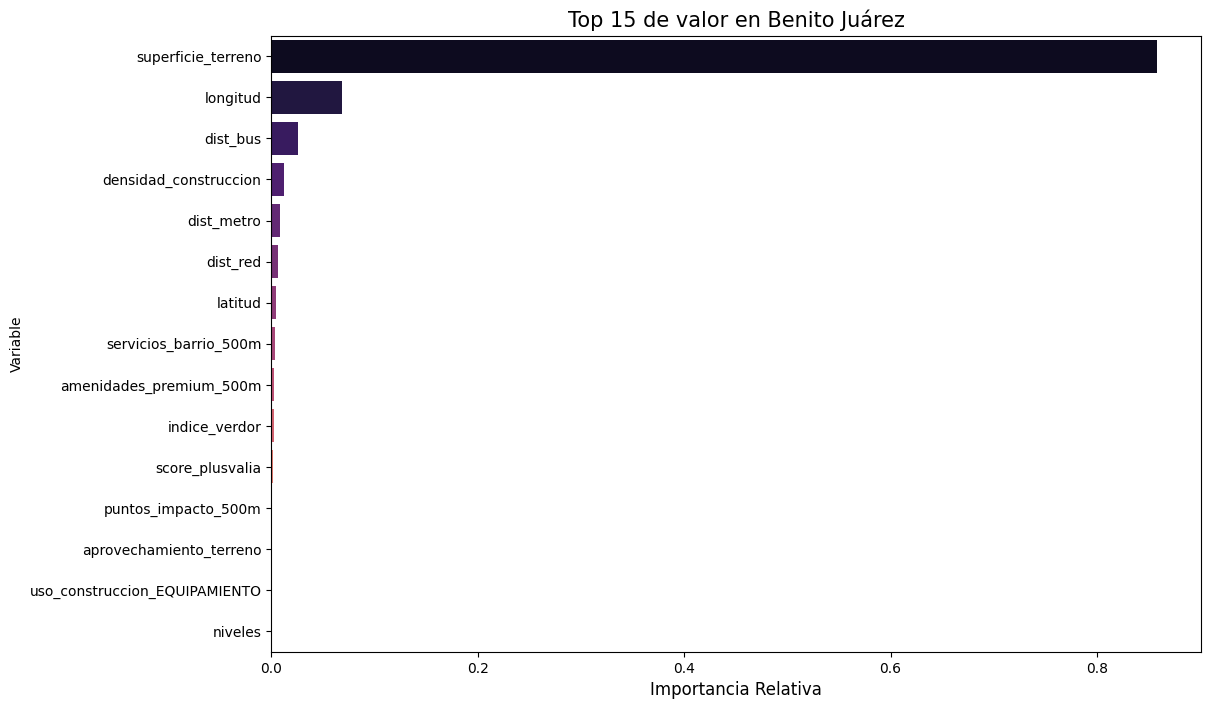

                   Variable  Importancia
0        superficie_terreno     0.858112
2                  longitud     0.068845
6                  dist_bus     0.025660
8     densidad_construccion     0.012723
5                dist_metro     0.008686
7                  dist_red     0.006807
1                   latitud     0.004331
11    servicios_barrio_500m     0.003281
9   amenidades_premium_500m     0.002664
12            indice_verdor     0.002634


In [50]:
importancia = pd.DataFrame({
    'Variable':X.columns,
    'Importancia': random_forest.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x='Importancia', y='Variable', data=importancia.head(15), palette='magma')
plt.title('Top 15 de valor en Benito Juárez', fontsize=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.show()

print(importancia.head(10))

## Identificación de posibles lugares infravalaorados

In [51]:
#Usaremos todo el dataset para buscar posibles zonas de inversión
pred_totales = random_forest.predict(X)

#Copiamos el Df antes de pasar al modelo
df_oportunidades = gdf_final_uso_cat.copy()
df_oportunidades['valor_modelo'] = pred_totales 
df_oportunidades['gap_valor'] = df_oportunidades['valor_modelo'] - df_oportunidades['valor_suelo']
df_oportunidades['pct_valor'] = (df_oportunidades['gap_valor'] /df_oportunidades['valor_suelo']) * 100

#Se filtran las oportunidades de crecimiento
top_oportunidades = df_oportunidades[
    (df_oportunidades['pct_valor']>30) &
    (df_oportunidades['score_plusvalia'] > 40) 
].sort_values(by='gap_valor', ascending=False)

print(f'Se han encontrado : {len(top_oportunidades)}')
print(top_oportunidades[['colonia', 'valor_suelo','valor_modelo','gap_valor','score_plusvalia']].head(10))


Se han encontrado : 48
                       colonia   valor_suelo  valor_modelo     gap_valor  \
52141  EXTREMADURA INSURGENTES  7.508867e+06  1.421647e+07  6.707608e+06   
44960      INSURGENTES MIXCOAC  1.282232e+07  1.928267e+07  6.460351e+06   
45269                  MIXCOAC  1.784968e+07  2.404355e+07  6.193871e+06   
52138  EXTREMADURA INSURGENTES  8.768202e+06  1.412728e+07  5.359077e+06   
76673          STA CRUZ ATOYAC  7.785849e+06  1.176552e+07  3.979671e+06   
31894  SAN PEDRO DE LOS  PINOS  3.472841e+06  7.113349e+06  3.640508e+06   
87603                  MODERNA  3.121996e+06  6.367414e+06  3.245418e+06   
44394      INSURGENTES MIXCOAC  8.791772e+06  1.160998e+07  2.818203e+06   
46706     SAN JOSE INSURGENTES  5.542463e+06  7.568060e+06  2.025596e+06   
41663                 NONOALCO  3.251023e+06  5.251634e+06  2.000612e+06   

       score_plusvalia  
52141        52.614480  
44960        48.400703  
45269        45.384336  
52138        51.571432  
76673        49

In [52]:
#Exporta la base de datos a un csv para usarlo en streamlit

columnas_dashboard = [
    'latitud', 'longitud', 'colonia', 
    'valor_suelo', 'valor_modelo', 'gap_valor', 'pct_valor',
    'score_plusvalia', 'dist_metro', 'dist_bus', 
    'amenidades_premium_500m', 'servicios_barrio_500m',
    'niveles', 'potencial_niveles','dist_red'
]

df_export = df_oportunidades[columnas_dashboard]

df_export.to_csv(".\oportunidades_bj2.csv", index=False)

<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Carlos\AppData\Local\Temp\ipykernel_14424\3911110437.py:13: SyntaxWarning: invalid escape sequence '\o'
  df_export.to_csv(".\oportunidades_bj2.csv", index=False)


In [53]:
print(df_oportunidades.columns.to_list())

['superficie_terreno', 'superficie_construccion', 'uso_construccion', 'clave_rango_nivel', 'anio_construccion', 'valor_unitario_suelo', 'valor_suelo', 'latitud', 'longitud', 'colonia', 'geometry', 'us_dscr', 'niveles', 'are_lbr', 'dist_metro', 'dist_bus', 'dist_red', 'densidad_construccion', 'amenidades_premium_500m', 'puntos_impacto_500m', 'servicios_barrio_500m', 'indice_verdor', 'potencial_niveles', 'aprovechamiento_terreno', 'score_plusvalia', 'valor_modelo', 'gap_valor', 'pct_valor']


## Paso extra creación de dataframe para mapa intereactivo en Streamlit

In [54]:
capas_interes = ['metro_est_bj', 'bus_est_bj','red_transporte_pasajero_prd_bj']

for capa in capas_interes:
    print(mis_gdfs_finales[capa].head())

     sistema           nombre linea est  cve_est cve_eod17        tipo  \
0  STC Metro         PORTALES    02  21  STC0221     05055  Intermedia   
1  STC Metro        NATIVITAS    02  20  STC0220     05050  Intermedia   
2  STC Metro  VILLA DE CORTÉS    02  19  STC0219     05062  Intermedia   
3  STC Metro             XOLA    02  18  STC0218     05063  Intermedia   
4  STC Metro         VIADUCTO    02  17  STC0217     05061  Intermedia   

                   alcaldias   año                            geometry  
0              Benito Juárez  1970  POINT Z (2799424.573 822123.441 0)  
1              Benito Juárez  1970  POINT Z (2799548.558 823186.658 0)  
2              Benito Juárez  1970   POINT Z (2799659.52 824077.499 0)  
3              Benito Juárez  1970   POINT Z (2799763.253 824921.79 0)  
4  Benito Juárez / Iztacalco  1970  POINT Z (2799845.932 825548.101 0)  
    sistema                     nombre linea est cve_eod17        tipo  \
0  Metrobús  TEATRO DE LOS INSURGENTES    0

In [55]:
#Creación de gdf_movilidad. No tocar!
# Lista de las capas que quieres procesar
capas_movilidad = ['metro_est_bj', 'bus_est_bj','red_transporte_pasajero_prd_bj']
lista_final = []

for nombre_capa in capas_movilidad:
    if nombre_capa in mis_gdfs_finales:
        gdf = mis_gdfs_finales[nombre_capa].copy()
        
        # 1. Extraer coordenadas de la geometría
        # Asumiendo que son puntos (Point)
        gdf['lat'] = gdf.geometry.y
        gdf['lon'] = gdf.geometry.x
        
        # 2. Seleccionar solo lo necesario
        # Usamos 'nombre' o 'est' dependiendo de cuál tenga el dato en tu GDF
        cols_a_mantener = ['nombre', 'sistema', 'linea', 'lat', 'lon']
        # Filtramos solo las columnas que existan para evitar errores
        cols_presentes = [c for c in cols_a_mantener if c in gdf.columns]
        
        df_limpio = pd.DataFrame(gdf[cols_presentes])
        lista_final.append(df_limpio)

# 3. Unir todo en una sola tabla de "Infraestructura"
df_movilidad = pd.concat(lista_final, ignore_index=True)

In [56]:
import geopandas as gpd
import pandas as pd

# 1. Aseguramos que la movilidad sea un GeoDataFrame (GDF)
# Usamos df_movilidad que tiene lat y lon
gdf_movilidad = gpd.GeoDataFrame(
    df_movilidad, 
    geometry=gpd.points_from_xy(df_movilidad.lon, df_movilidad.lat),
    crs="EPSG:4326"
)

# 2. IMPORTANTE: Ambos deben estar en la misma proyección (metros) para el buffer
# Usamos la misma que usaste en tu módulo previo
gdf_movilidad = gdf_movilidad.to_crs(gdf_final_uso_cat.crs)

# 3. Creamos el buffer de 500m (reusando tu lógica)
gdf_buffer_mov = gdf_final_uso_cat[['geometry']].copy()
gdf_buffer_mov['geometry'] = gdf_buffer_mov.geometry.buffer(500)

# 4. Join Espacial: Aquí cruzamos las estaciones con los buffers de tus predios
# Usamos 'inner' para obtener solo las estaciones que SÍ están cerca de un predio
join_movilidad = gpd.sjoin(gdf_movilidad, gdf_buffer_mov, how="inner", predicate="intersects")

# 5. Formateo para el Mapa
# 'index_right' es el ID de tu predio original. 
# Necesitamos regresar a Lat/Lon (WGS84) para que PyDeck lo lea
join_movilidad_mapa = join_movilidad.to_crs(epsg=4326)

# Creamos la tabla final de relaciones
df_relaciones_estaciones = pd.DataFrame({
    'id_predio': join_movilidad_mapa['index_right'],
    'nombre_estacion': join_movilidad_mapa['nombre'],
    'sistema': join_movilidad_mapa['sistema'],
    'linea': join_movilidad_mapa['linea'],
    'lat_estacion': join_movilidad_mapa.geometry.y,
    'lon_estacion': join_movilidad_mapa.geometry.x
})

print(f"✅ ¡Éxito! Se encontraron {len(df_relaciones_estaciones)} conexiones estación-predio.")
print(df_relaciones_estaciones.head())

✅ ¡Éxito! Se encontraron 0 conexiones estación-predio.
Empty DataFrame
Columns: [id_predio, nombre_estacion, sistema, linea, lat_estacion, lon_estacion]
Index: []


In [57]:
gdf_final = gpd.GeoDataFrame(
    df_relaciones_estaciones, 
    geometry=gpd.points_from_xy(df_relaciones_estaciones.lon_estacion, df_relaciones_estaciones.lat_estacion), 
    crs= "EPSG:6362"
)

gdf_en_grados = gdf_final.to_crs(epsg=4326)

df_estaciones_streamlit = pd.DataFrame({
    'id_predio': gdf_en_grados ['id_predio'],
    'nombre_estacion': gdf_en_grados ['nombre_estacion'],
    'sistema': gdf_en_grados ['sistema'],
    'linea': gdf_en_grados .get('linea'),
    'lat_estacion': gdf_en_grados .geometry.y, 
    'lon_estacion': gdf_en_grados .geometry.x  
})

# 3. Guardamos el archivo corregido
df_estaciones_streamlit.to_csv("./estaciones_cercanas.csv", index=False)

print("Misión cumplida! Revisa los números:")
print(df_estaciones_streamlit[['lat_estacion', 'lon_estacion']].head())

Misión cumplida! Revisa los números:
Empty DataFrame
Columns: [lat_estacion, lon_estacion]
Index: []


In [58]:
#Combinar df_movilidad_total y gdf_final_uso_cat

gdf_final_predio_mov = gdf_final_uso_cat[['colonia','valor_suelo','score_plusvalia','latitud','longitud','geometry']]
gdf_final_predio_mov.head() 

,colonia,valor_suelo,score_plusvalia,latitud,longitud,geometry
0,ALAMOS I,651519.04,29.299142,19.403473,-99.142873,POINT (2799214.711 825823.083)
1,ALAMOS I,587435.20,28.537691,19.403478,-99.142968,POINT (2799204.772 825823.334)
2,ALAMOS I,528691.68,28.450909,19.403482,-99.143053,POINT (2799195.813 825823.658)
3,ALAMOS I,512670.72,28.294532,19.403487,-99.143129,POINT (2799187.857 825824)
4,ALAMOS I,539372.32,24.215431,19.403491,-99.143206,POINT (2799179.823 825824.346)


In [62]:
# 1. Aseguramos que la movilidad sea un GeoDataFrame (GDF)
# Usamos df_movilidad que tiene lat y lon
gdf_movilidad = gpd.GeoDataFrame(
    gdf_movilidad, 
    geometry=gpd.points_from_xy(gdf_movilidad.lon, gdf_movilidad.lat),
    crs="EPSG:4326"
)

# 2. IMPORTANTE: Ambos deben estar en la misma proyección (metros) para el buffer
# Usamos la misma que usaste en tu módulo previo
gdf_movilidad = gdf_movilidad.to_crs(gdf_final_predio_mov.crs)

# 3. Creamos el buffer de 500m (reusando tu lógica)
gdf_buffer_mov = gdf_final_predio_mov[['geometry']].copy()
gdf_buffer_mov['geometry'] = gdf_buffer_mov.geometry.buffer(500)

# 4. Join Espacial: Aquí cruzamos las estaciones con los buffers de tus predios
# Usamos 'inner' para obtener solo las estaciones que SÍ están cerca de un predio
join_movilidad = gpd.sjoin(gdf_movilidad, gdf_buffer_mov, how="inner", predicate="intersects")

# 5. Formateo para el Mapa
# 'index_right' es el ID de tu predio original. 
# Necesitamos regresar a Lat/Lon (WGS84) para que PyDeck lo lea
join_movilidad_mapa = join_movilidad.to_crs(epsg=4326)

# Creamos la tabla final de relaciones
df_relaciones_estaciones = pd.DataFrame({
    'id_predio': join_movilidad_mapa['index_right'],
    'nombre_estacion': join_movilidad_mapa['nombre'],
    'sistema': join_movilidad_mapa['sistema'],
    'linea': join_movilidad_mapa['linea'],
    'lat_estacion': join_movilidad_mapa.geometry.y,
    'lon_estacion': join_movilidad_mapa.geometry.x
})

print(f"Se encontraron {len(df_relaciones_estaciones)} conexiones estación-predio.")
print(df_relaciones_estaciones.head())

Se encontraron 0 conexiones estación-predio.
Empty DataFrame
Columns: [id_predio, nombre_estacion, sistema, linea, lat_estacion, lon_estacion]
Index: []


In [ ]:
#Guardar para usar en la página
df_relaciones_estaciones.to_csv('.\estaciones_cercanas.csv', index=False)
# Nota: Quitamos la geometría para que el CSV sea ligero
gdf_final_uso_cat.drop(columns='geometry').to_csv('predios_master.csv', index=True)

<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Carlos\AppData\Local\Temp\ipykernel_2284\3639614420.py:2: SyntaxWarning: invalid escape sequence '\e'
  df_relaciones_estaciones.to_csv('.\estaciones_cercanas.csv', index=False)


## Creación df para mostrar puntos interés

In [ ]:
print(join_premium)

      Nombre de la Unidad Económica Código de la clase de actividad SCIAN  \
0             0494 SUBURBIA HOLBEIN                                462210   
0             0494 SUBURBIA HOLBEIN                                462210   
0             0494 SUBURBIA HOLBEIN                                462210   
0             0494 SUBURBIA HOLBEIN                                462210   
0             0494 SUBURBIA HOLBEIN                                462210   
...                             ...                                   ...   
12122                  ZONA CULICHI                                722512   
12122                  ZONA CULICHI                                722512   
12122                  ZONA CULICHI                                722512   
12122                  ZONA CULICHI                                722512   
12122                  ZONA CULICHI                                722512   

                         Nombre de clase de la actividad  \
0       Comerci

In [ ]:
print(join_premium.columns.to_list())

['Nombre de la Unidad Económica', 'Código de la clase de actividad SCIAN', 'Nombre de clase de la actividad', 'Descripcion estrato personal ocupado', 'Tipo de asentamiento humano', 'Nombre de asentamiento humano', 'Tipo centro comercial', 'Corredor industrial, centro comercial o mercado público', 'Número de local', 'Código Postal', 'Área geoestadística básica ', 'Tipo de establecimiento', 'Latitud', 'Longitud', 'geometry', 'index_right']


In [ ]:
# Definimos las columnas que realmente queremos ver en el mapa/tooltip
cols_interes = [
    'index_right', 
    'Nombre de la Unidad Económica', 
    'Nombre de clase de la actividad', 
    'Latitud', 
    'Longitud',
    'tipo_amenidad' # Esta la crearemos ahorita
]

# 2. Preparamos el GDF Premium
gdf_premium_mapa = join_premium.copy()
gdf_premium_mapa['tipo_amenidad'] = 'Premium'

# 3. Preparamos el GDF de Servicios Básicos (Barrio)
gdf_barrio_mapa = join_barrio.copy()
gdf_barrio_mapa['tipo_amenidad'] = 'Básico'

# 4. Unimos ambos en una sola tabla de "Lugares Cercanos"
df_amenidades_final = pd.concat([
    gdf_premium_mapa[cols_interes], 
    gdf_barrio_mapa[cols_interes]
], ignore_index=True)

# 5. Renombramos para que sea más fácil de usar en el código
df_amenidades_final.rename(columns={
    'index_right': 'id_predio',
    'Nombre de la Unidad Económica': 'nombre',
    'Nombre de clase de la actividad': 'categoria'
}, inplace=True)

print(f"Análisis de entorno completado.")
print(f"Total de amenidades mapeadas: {len(df_amenidades_final)}")

Análisis de entorno completado.
Total de amenidades mapeadas: 3369733


In [ ]:
#Como se puede ver tenemos 3 millones de amenidades lo cuál hará que la página se relentice para evitar eso se hará lo siguiente:
# 1. Ordenamos por tipo y nos quedamos con un máximo de 10 de cada una por predio
df_amenidades_top = df_amenidades_final.groupby(['id_predio', 'tipo_amenidad']).head(10)

# 2. Guardamos este archivo optimizado
df_amenidades_top.to_csv('amenidades_cercanas_opt.csv', index=False)

print(f"Archivo optimizado: Pasamos de {len(df_amenidades_final)} a {len(df_amenidades_top)} registros.")

Archivo optimizado: Pasamos de 3369733 a 1735258 registros.
